# Battery Life Prediction Using ResNet-CNN and Bayesian Transfer Learning

## Overview
This notebook implements a two-stage machine learning approach for lithium-ion battery cycle life prediction using voltage features (VF) extracted from early charging cycles. The methodology combines a Residual Convolutional Neural Network (ResNet-CNN) for initial predictions with Bayesian optimization for enhanced accuracy.

## Methodology
**Stage 1**: ResNet-CNN model trained on voltage-time sequences from early battery cycles to predict total cycle life
**Stage 2**: Bayesian framework using polynomial aging models to refine Stage 1 predictions through transfer learning

## Datasets Used
**MIT Battery Dataset**: Primary training dataset containing 124 batteries from MIT's second batch experiments
**NASA Battery Dataset**: External validation dataset for transfer learning evaluation (32 batteries (Used 18): B0005-B0007, B0018, B0025-B0028 etc...)

## Key Results

### Part 1: MIT Dataset Replication
- **Stage 1 Performance**: R² = 0.9676, MAE = 26.83 cycles, MAPE = 3.367 %, RMSE = 31.17 cycles
- **Stage 2 Performance**: R² = 0.9513, MAE =  0.0145 Ah, MAPE = 1.6471 %(trajectory prediction)

### Part 2: Transfer Learning Performance

#### Zero-Shot Transfer (MIT → NASA) 
- **Stage 1**: Poor performance due to domain mismatch between MIT and NASA datasets
- **Stage 2**: Poor performance


#### Few-Shot Transfer (Fine-tuned on NASA)
- **Stage 1**: R² = 0.41 (when fine-tuning with >8 batteries)
- **Stage 2**: R² = 0.77 (Battery index 11)

## Technical Implementation
- **Architecture**: Custom ResNet-CNN with residual blocks for temporal sequence modeling
- **Features**: Voltage at fixed capacity (VF) extracted from charging curves
- **Training**: 70/30 train-test split of the early 30% of the data , Adam optimizer, early stopping
- **Transfer Learning**: Both zero-shot and few-shot approaches evaluated
- **Bayesian Optimization**: Polynomial aging models with uncertainty quantification

## Key Findings
The model demonstrates excellent performance on the original MIT dataset with strong generalization within the same domain. However, transfer learning reveals significant challenges:

**Zero-Shot Limitations**: The MIT-trained model showed poor performance when directly applied to NASA data without fine-tuning. This is attributed to fundamental differences between datasets including varying cycle life ranges, capacity ranges, and underlying battery degradation patterns.

**Few-Shot Improvements**: Fine-tuning the MIT model on NASA data significantly improved performance, demonstrating the model's adaptability when provided with target domain examples. However, results were limited by the small size and noisy nature of the NASA dataset.

**Transfer Learning Potential**: While current results show mixed success, the few-shot improvements suggest that with larger, cleaner datasets and proper fine-tuning strategies, the MIT model architecture could be effectively transferred to other battery datasets. This hypothesis requires validation with more comprehensive datasets in future work.

### This Notebook has consist of two Parts:

- Part 1: Replicating the Papers results using the MIT second Batch data set :

    * Data loading and VF feature extraction  
    Stage 1 ResCNN Model and Stage 2 Fraemwork
    Training stage the ResCNN Model
    base aging model and Bayes Inferenz 

- Part 2 : Trying to transfer/evaluate the model on other Datasets with two Approaches: 1- Zero-Shot Approach 2- Few-Shot approach (Model fine tunning)

    * Nasa Dataset: 



# Part 1 

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
import os
import psutil
import gc
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(" All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

 All libraries imported successfully
PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda


In [ ]:
# Data Loading Functions

def extract_vf_immediately(cycle_data, target_capacity=0.9):
    """Extract VF value immediately and discard raw voltage data"""
    try:
        if 'Qc' in cycle_data and 'V' in cycle_data:
            qc_data = cycle_data['Qc']
            voltage_data = cycle_data['V']
            
            if len(qc_data) > 0 and len(voltage_data) > 0:
                qc_array = np.array(qc_data).flatten()
                v_array = np.array(voltage_data).flatten()
                
                if target_capacity <= np.max(qc_array):
                    idx = np.argmin(np.abs(qc_array - target_capacity))
                    vf_value = v_array[idx]
                    return float(vf_value)
        return None
    except Exception as e:
        return None

def load_battery_streaming(file_path, early_cycle_percentage=0.3):
    """Load battery with immediate VF extraction for ALL early cycles (30%)"""
    try:
        filename = os.path.basename(file_path)
        print(f"Processing {filename[:25]}...", end=" ", flush=True)
        
        with open(file_path, 'r') as f:
            data = json.load(f)
        print("loaded...", end=" ", flush=True)
        
        if 'summary' not in data:
            print("Missing data structure")
            return None
        
        # Get discharge capacity
        summary = data['summary']
        discharge_capacity = []
        
        if 'discharge_capacity' in summary:
            discharge_capacity = np.array(summary['discharge_capacity']).flatten()
        elif 'QDischarge' in summary:
            discharge_capacity = np.array(summary['QDischarge']).flatten()
        
        if len(discharge_capacity) < 100:
            print("Insufficient cycles")
            return None
        
        # Calculate early cycle split
        total_cycles = len(discharge_capacity)
        early_cycle_count = int(early_cycle_percentage * total_cycles)
        
        print(f"extracting VF for {early_cycle_count} early cycles...", end=" ", flush=True)
        
        # Extract VF values from cycles_interpolated
        vf_values = {}
        if 'cycles_interpolated' in data:
            cycles_data = data['cycles_interpolated']
            voltages = np.array(cycles_data['voltage'])
            currents = np.array(cycles_data['current'])
            cycle_indices = np.array(cycles_data['cycle_index'])
            
            for cycle_idx in range(early_cycle_count):
                cycle_mask = cycle_indices == cycle_idx
                cycle_voltages = voltages[cycle_mask]
                cycle_currents = currents[cycle_mask]
                
                if len(cycle_voltages) < 10:
                    continue
                
                # Find charging points
                charging_mask = cycle_currents > 0
                if not np.any(charging_mask):
                    continue
                
                charging_voltages = cycle_voltages[charging_mask]
                charging_currents = cycle_currents[charging_mask]
                
                if len(charging_voltages) < 10:
                    continue
                
                # Calculate capacity and find VF at 0.9 Ah
                dt = 1.0
                cumulative_capacity = np.cumsum(charging_currents) * dt / 3600
                target_capacity = 0.9
                
                if target_capacity <= np.max(cumulative_capacity):
                    idx = np.argmin(np.abs(cumulative_capacity - target_capacity))
                    vf_value = charging_voltages[idx]
                    vf_values[cycle_idx] = float(vf_value)
        
        # Return minimal battery data
        battery_minimal = {
            'name': os.path.basename(file_path).replace('.json', ''),
            'discharge_capacity': discharge_capacity,
            'early_cycles': discharge_capacity[:early_cycle_count],
            'remaining_cycles': discharge_capacity[early_cycle_count:],
            'total_cycles': total_cycles,
            'early_cycle_count': early_cycle_count,
            'vf_values': vf_values,
            'cycle_life': total_cycles
        }
        
        print(f" {len(vf_values)} VF sequences, {total_cycles} cycles")
        return battery_minimal
        
    except Exception as e:
        print(f" Error: {str(e)[:30]}")
        return None

def process_vf_to_sequence(vf_values_dict):
    """Convert VF values dict to CNN input format (1000, 2, 1)"""
    if len(vf_values_dict) < 10:
        return None
    
    cycle_indices = sorted(vf_values_dict.keys())
    vf_values = [vf_values_dict[idx] for idx in cycle_indices]
    
    # Pad to 1000 length 
    vf_padded = pad_to_length(np.array(vf_values), 1000)
    cycle_indices_padded = pad_to_length(np.array(cycle_indices), 1000)
    
    # Papers format: 
    vf_sequence = np.stack([vf_padded, cycle_indices_padded], axis=1)
    vf_sequence = vf_sequence.reshape(1000, 2, 1)
    
    return vf_sequence

def pad_to_length(array, target_length):
    """Pad or truncate array to target length"""
    if len(array) >= target_length:
        return array[:target_length]
    else:
        padding = np.full(target_length - len(array), array[-1] if len(array) > 0 else 0)
        return np.concatenate([array, padding])

def load_zhou_dataset_streaming_full_early(data_path, max_batteries=40, early_cycle_percentage=0.3):
    """Stream-load Zhou dataset extracting ALL VF sequences in early cycle period"""
    print("="*60)
    print("STREAMING ZHOU DATASET LOADING - FULL EARLY CYCLE VF EXTRACTION")
    print("="*60)
    
    # Get battery files
    all_files = [f for f in os.listdir(data_path) 
                 if f.startswith('2019-01-24') and f.endswith('.json')]
    
    # Remove duplicates by battery name
    battery_files = {}
    for filename in all_files:
        if 'batch9' in filename and '_structure.json' in filename:
            parts = filename.replace('_structure.json', '').split('_')
            if len(parts) >= 3:
                battery_name = parts[-1]
                if battery_name.startswith('CH') and battery_name not in battery_files:
                    battery_files[battery_name] = filename
    
    unique_files = list(battery_files.values())[:max_batteries]
    print(f"Processing {len(unique_files)} files (limited to {max_batteries} for RAM management)")
    print(f"Extracting VF sequences for COMPLETE early cycle period ({early_cycle_percentage*100:.0f}%)")
    
    batteries = []
    vf_sequences_list = []
    cycle_lives = []
    
    for i, filename in enumerate(unique_files):
        file_path = os.path.join(data_path, filename)
        
        # Monitor RAM
        ram_gb = psutil.Process().memory_info().rss / 1024**3
        print(f"[{i+1:2d}/{len(unique_files)}] RAM: {ram_gb:.1f}GB - ", end="")
        
        if ram_gb > 14:
            print("RAM limit approached - stopping")
            break
        
        # Load battery with minimal memory footprint
        battery_data = load_battery_streaming(file_path, early_cycle_percentage)
        
        if battery_data is not None:
            # Process VF sequence immediately
            vf_sequence = process_vf_to_sequence(battery_data['vf_values'])
            
            if vf_sequence is not None:
                batteries.append({
                    'name': battery_data['name'],
                    'early_cycles': battery_data['early_cycles'],
                    'remaining_cycles': battery_data['remaining_cycles'],
                    'cycle_life': battery_data['cycle_life'],
                    'early_cycle_count': battery_data['early_cycle_count'],
                    'vf_count': len(battery_data['vf_values'])
                })
                
                vf_sequences_list.append(vf_sequence)
                cycle_lives.append(battery_data['cycle_life'])
            
        # Force garbage collection
        del battery_data
        gc.collect()
    
    # Convert to final arrays
    if len(vf_sequences_list) > 0:
        vf_array = np.array(vf_sequences_list)
        cycle_lives_array = np.array(cycle_lives)
        
        final_ram = psutil.Process().memory_info().rss / 1024**3
        print(f"\nFinal dataset: {len(batteries)} batteries, RAM: {final_ram:.1f}GB")
        print(f"VF sequences shape: {vf_array.shape}")
        
        return {
            'batteries': batteries,
            'vf_sequences': vf_array,
            'cycle_lives': cycle_lives_array
        }
    else:
        print("No valid batteries processed!")
        return None

print("Data loading functions defined")

Data loading functions defined


In [681]:
# Load MIT Battery Data
print("Loading MIT battery data")

# Try to load from pickle first (fast)
pkl_path = r'C:\Users\Zakar\lfp-battery-degradation\data\processed\streaming_dataset_full.pkl'
try:
    import pickle
    with open(pkl_path, 'rb') as f:
        streaming_dataset_full = pickle.load(f)
    #print(f" Loaded dataset from pickle: {len(streaming_dataset_full)} batteries")
except (FileNotFoundError, Exception) as e:
    print(" Pickle not found, loading from raw data...")
    
    # Original loading code
    data_path = r'C:\Users\Zakar\lfp-battery-degradation\data\raw'
    streaming_dataset_full = load_zhou_dataset_streaming_full_early(
        data_path=data_path, 
        max_batteries=45,
        early_cycle_percentage=0.3
    )
    
    if streaming_dataset_full is None:
        print("ERROR: Could not load dataset")
    else:
        # Save to pickle for next time
        import os
        os.makedirs(os.path.dirname(pkl_path), exist_ok=True)
        with open(pkl_path, 'wb') as f:
            pickle.dump(streaming_dataset_full, f)
        print(f" Saved dataset to pickle: {pkl_path}")

Loading MIT battery data


In [682]:
# Setup and Data Preparation
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

# Load the pre-processed dataset 
# if  'streaming_dataset_full.pkl' exists:
pkl_path = r'C:\Users\Zakar\lfp-battery-degradation\data\processed\streaming_dataset_full.pkl'
try:
    with open(pkl_path, 'rb') as f:
        dataset = pickle.load(f)
    print(f"Successfully loaded dataset with {len(dataset['batteries'])} batteries.")
except FileNotFoundError:
    print("ERROR: Pickle file not found. Please run your data loading script first.")
    # Exit or handle the error appropriately
    exit()

# Extract data for the Res-CNN model
# vf_sequences shape: (num_batteries, 1000, 2, 1) -> (vf_value, cycle_index)
# cycle_lives shape: (num_batteries,)
vf_sequences = dataset['vf_sequences']
cycle_lives = dataset['cycle_lives']
batteries_data = dataset['batteries']

# The paper uses a (1000, 2, 1) sequence. PyTorch Conv2D expects (N, C, H, W).
# reshape from (N, H, W, C) to (N, C, H, W) where C=1.
X = np.transpose(vf_sequences, (0, 3, 1, 2)) # Shape: (40, 1, 1000, 2)
y = cycle_lives.reshape(-1, 1) # Shape: (40, 1)

#Train-Test Split (70/30 split semae as the paper) 
X_train, X_test, y_train, y_test, batteries_train, batteries_test = train_test_split(
    X, y, batteries_data, test_size=0.3, random_state=42
)

# Z-score Normalization
# normalize the VF feature (first channel of the width dimension 'W')
# Scaler for VF values
vf_scaler = StandardScaler()
X_train[:, 0, :, 0] = vf_scaler.fit_transform(X_train[:, 0, :, 0])
X_test[:, 0, :, 0] = vf_scaler.transform(X_test[:, 0, :, 0])

# Scaler for cycle indices
cycle_scaler = StandardScaler()
X_train[:, 0, :, 1] = cycle_scaler.fit_transform(X_train[:, 0, :, 1])
X_test[:, 0, :, 1] = cycle_scaler.transform(X_test[:, 0, :, 1])

# Scaler for the target (cycle life)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Create PyTorch DataLoaders 
batch_size = 32 # A reasonable batch size, paper uses 64 but our dataset is smaller

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train_scaled))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test_scaled))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Data Preparation Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Successfully loaded dataset with 45 batteries.
Data Preparation Complete.
X_train shape: (31, 1, 1000, 2)
y_train shape: (31, 1)
Train batches: 1, Test batches: 1


In [606]:
#Step 2 - Res-CNN Model Definition
import torch
import torch.nn as nn

class ResCNN(nn.Module):
    def __init__(self):
        super(ResCNN, self).__init__()
        # Input shape: (N, 1, 1000, 2)

        # Initial Convolution
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # First Residual Block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Second Residual Block with channel increase
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.shortcut_conv1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, stride=1) # To match dimensions

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        # Third Residual Block with channel increase
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(96)
        self.shortcut_conv2 = nn.Conv2d(in_channels=64, out_channels=96, kernel_size=1, stride=1) # To match dimensions

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5) # As per Table 1

        # Pooling and Fully Connected Layers
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(96, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # Initial Conv
        x = self.relu(self.bn1(self.conv1(x)))

        # First Res Block
        identity1 = x
        out = self.relu(self.bn2(self.conv2(x)))
        out = out + identity1 # Shortcut connection
        out = self.relu(out)

        # Second Res Block
        identity2 = self.shortcut_conv1(out)
        out = self.relu(self.bn3(self.conv3(out)))
        out = self.relu(self.bn4(self.conv4(out)))
        out = out + identity2 # Shortcut connection
        out = self.relu(out)
        
        # Third Res Block
        identity3 = self.shortcut_conv2(out)
        out = self.relu(self.bn5(self.conv5(out)))
        out = out + identity3
        out = self.relu(out)
        
        out = self.dropout(out)

        # FC layers
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

print("Res-CNN model defined.")

Res-CNN model defined.


In [683]:
#Step 3 - Training the Res-CNN Model
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters (Zweite Tabelle))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResCNN().to(device)
learning_rate = 0.0001
epochs = 100 # Maximum iterations
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01) # Paper uses AdamW with weight decay

print(f"Training on {device}...")

history = {'train_loss': [], 'test_loss': []}

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    
    # Using tqdm for a progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_pbar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = running_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # Validation  
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]")
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            test_pbar.set_postfix({'loss': loss.item()})

    avg_test_loss = running_test_loss / len(test_loader)
    history['test_loss'].append(avg_test_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

print("Training finished.")

Training on cuda...


Epoch 1/100 [Train]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/100 [Test]: 100%|██████████| 1/1 [00:00<?, ?it/s, loss=1.01]


Epoch 1/100 - Train Loss: 1.0517, Test Loss: 1.0138


Epoch 2/100 [Test]: 100%|██████████| 1/1 [00:00<00:00, 219.13it/s, loss=1.01]


...

Epoch 98/100 - Train Loss: 0.0011, Test Loss: 0.0320


Epoch 99/100 [Test]: 100%|██████████| 1/1 [00:00<00:00, 79.06it/s, loss=0.0321]


Epoch 99/100 - Train Loss: 0.0011, Test Loss: 0.0321


Epoch 100/100 [Test]: 100%|██████████| 1/1 [00:00<00:00, 123.76it/s, loss=0.0321]

Epoch 100/100 - Train Loss: 0.0010, Test Loss: 0.0321
Training finished.


--- Cycle Life Prediction Performance (Test Set) ---
MAE: 26.830 cycles
RMSE: 31.172 cycles
MAPE: 3.367 %
R²: 0.9676

Standard Deviation of Prediction Errors: 31.14 (used for Bayesian prior 'v0')


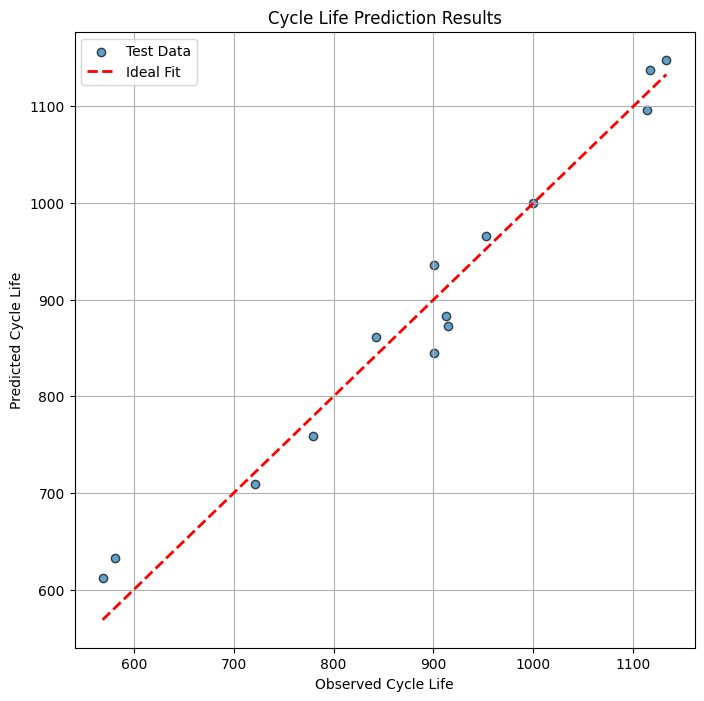

In [684]:
# Step 4 - Evaluating
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Get predictions for the test set---
model.eval()
y_pred_scaled_list = []
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        y_pred_scaled_list.extend(outputs.cpu().numpy())

y_pred_scaled = np.array(y_pred_scaled_list)

# Inverse transform to get actual cycle life values
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_test_actual = y_test

# metrics
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mape = mean_absolute_percentage_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("--- Cycle Life Prediction Performance (Test Set) ---")
print(f"MAE: {mae:.3f} cycles")
print(f"RMSE: {rmse:.3f} cycles")
print(f"MAPE: {mape:.3f} %")
print(f"R²: {r2:.4f}")

# Calculate the standard deviation of prediction errors for the Bayesian prior
prediction_errors = y_test_actual - y_pred
std_dev_prediction_error = np.std(prediction_errors)
print(f"\nStandard Deviation of Prediction Errors: {std_dev_prediction_error:.2f} (used for Bayesian prior 'v0')")


# Visualize results
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_pred, alpha=0.7, edgecolors='k', label='Test Data')
plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Observed Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title("Cycle Life Prediction Results")
plt.legend()
plt.grid(True)
plt.show()

In [685]:
# Cell to Save the Trained Res-CNN Model

# Define a path and filename for the saved model
model_save_path = 'resnet_cycle_predictor.pth'

# Save the model's state dictionary (the learned weights)
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: resnet_cycle_predictor.pth


In [10]:
# Step 5 Transfer Learning Framework
from scipy.optimize import curve_fit
import emcee
import corner

# Empirical Aging Model (Eq. 1)
def empirical_model(x, theta1, theta2, theta3, theta4):
    return theta1 * np.exp(theta2 * x) + theta3 * np.exp(theta4 * x)

# Transferred Model (Eq. 4)
def transferred_model(params, x_new, base_model_params):
    rho0, lambda0, rho1, lambda1 = params
    theta1, theta2, theta3, theta4 = base_model_params
    
    x_old = rho0 * x_new + lambda0
    C_old = empirical_model(x_old, theta1, theta2, theta3, theta4)
    C_new = rho1 * C_old + lambda1
    return C_new

# Bayesian Framework (Log Probability Functions)
# This part implements the logic from Eq. 7 through 16.
def log_likelihood(params, x_obs, y_obs, base_model_params, log_sigma):
    y_pred = transferred_model(params, x_obs, base_model_params)
    sigma = np.exp(log_sigma)
    return -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)

def log_prior(params, predicted_cycle_life, v0):
    rho0, lambda0, rho1, lambda1 = params
    
    # Prior for rho0, lambda0 derived from predicted cycle life (Eq. 12)
    # rho0 = (x_old_max - x_old_min) / (x_new_max - x_new_min)
    # Here, x_old_min = x_new_min = 1. x_old_max is cycle life of source, x_new_max is predicted.
    # model the distribution of the predicted cycle life.
    # This is a simplification; a more complex prior could be built.
    # A simple approach is to penalize deviations from the expected cycle life.
    # The paper suggests p(Cycle_pred) ~ N(mu0, v0). We'll model this for x_new_max.
    # For this implementation, setting a normal prior on the predicted cycle life itself.
    # The actual sampler will solve for parameters that result in this cycle life.
    
    # Priors for rho1, lambda1 (Eq. 13) are N([1, 0], v1)
    mu1 = np.array([1.0, 0.0])
    v1 = 0.1 # Small variance as was suggested in paper
    prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)

    # For rho0, lambda0, use an uninformative prior for simplicity in this implementation,
    # as the likelihood and cycle life constraint will dominate.
    
    return prior_rho1_lambda1 #  will enforce the cycle life prediction in the full probability

def log_probability(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    params = params_with_sigma[:-1] # rho0, lambda0, rho1, lambda1
    log_sigma = params_with_sigma[-1]
    
    lp = log_prior(params, predicted_cycle_life, v0)
    if not np.isfinite(lp):
        return -np.inf
    
    # Calculate cycle life from current params
    # the source battery's cycle life for this
    source_cycle_life = base_model_params[-1] # append to the params tuple
    rho0, lambda0, _, _ = params
    # x_old_max = rho0 * x_new_max + lambda0 -> x_new_max = (x_old_max - lambda0) / rho0
    if rho0 == 0: return -np.inf # Avoidinf division by zero
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    
    # Add the cycle life prior based on the Res-CNN prediction
    cycle_life_prior = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2

    ll = log_likelihood(params, x_obs, y_obs, base_model_params[:-1], log_sigma)
    
    return lp + ll + cycle_life_prior


print("Transfer learning framework and Bayesian functions defined.")

Transfer learning framework and Bayesian functions defined.


In [13]:
# pip install emcee
# pip install corner

In [ ]:
#initial_capacity

1.0472816

Attempting to fit base model with a global optimizer (Basin Hopping)...
Global optimization finished.


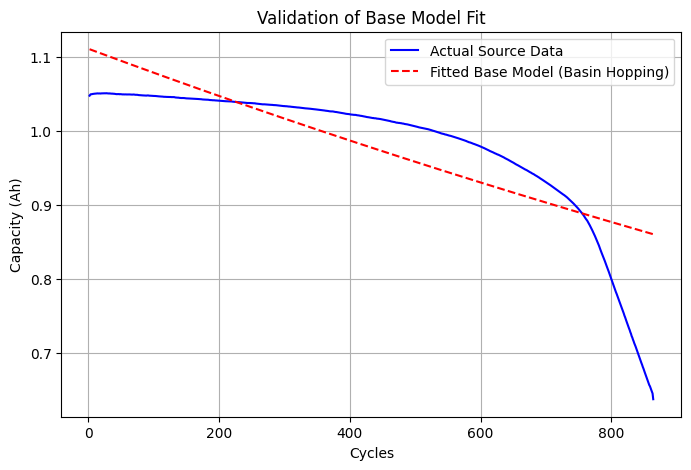


Cycle life prediction for '2019-01-24_batch9_CH6_structure':
Predicted: 977 cycles, True: 1000 cycles

Running MCMC sampler with globally optimized base model...


100%|██████████| 5000/5000 [00:09<00:00, 512.85it/s]



Estimated Transfer Parameters (Posterior Median):
rho0: 0.7259, lambda0: 0.5482 (derived), rho1: 0.5202, lambda1: 0.4987


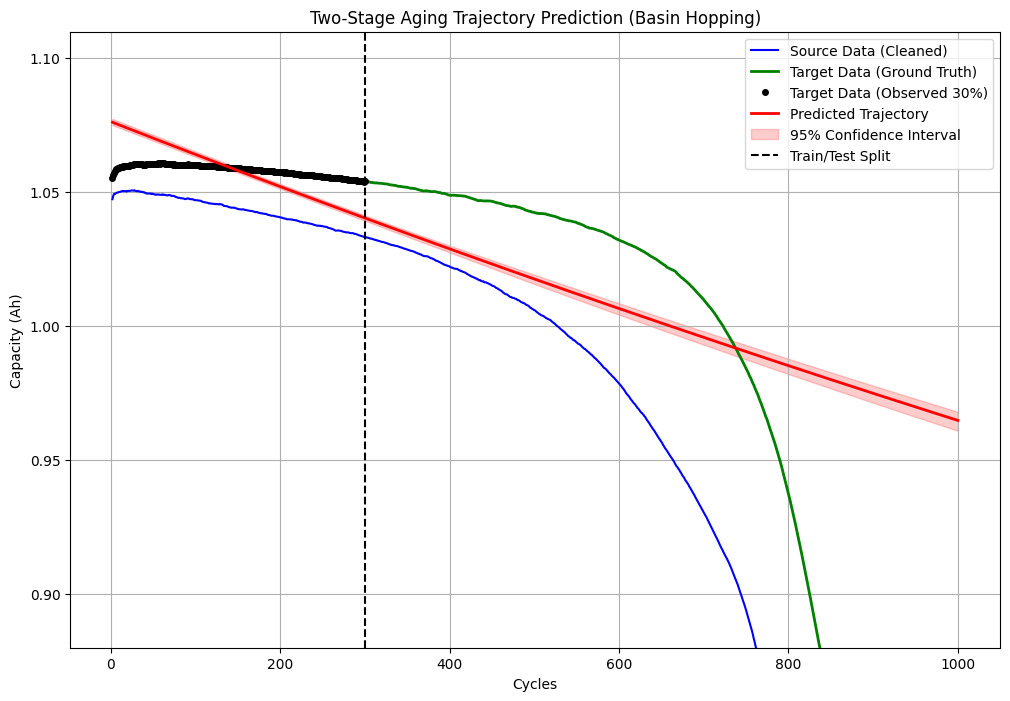


--- Final Trajectory Prediction Performance ---
R²: 0.0584
MAE: 0.0867 Ah
RMSE: 0.1563 Ah


In [ ]:
# Step 6:Using a Global Optimizer (Basin Hopping) for the Base Model -(we can use other optimizers as well)
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, basinhopping
import emcee
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  Data Preparation with Anomaly Removal 
#  the same source/target for a direct comparison
source_battery_index = 1
target_battery_index = 5

source_battery = batteries_data[source_battery_index]
source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
source_capacity = source_capacity_raw[1:]; source_cycles = source_cycles_raw[1:]

target_battery = batteries_test[target_battery_index]
target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
target_capacity_full = target_capacity_full_raw[1:]; target_cycles_full = target_cycles_full_raw[1:]
observed_cycles = np.arange(2, target_battery['early_cycle_count'] + 1); observed_capacity = target_battery['early_cycles'][1:]

#   Train Base Model with Basin Hopping 
print("Attempting to fit base model with a global optimizer (Basin Hopping)...")

# Define an objective function for the optimizer ---
# this calculates the sum of squared errors, which the optimizer will try to minimize.
def objective_function(theta, x_data, y_data):
    return np.sum((y_data - empirical_model(x_data, *theta))**2)

# Set up initial guesses and bounds, similar to before
initial_capacity = source_capacity[0]
initial_guesses = [initial_capacity - 0.2, -1e-5, 0.2, -1e-3]
bounds = ([0, -np.inf, 0, -np.inf], [np.inf, 0, np.inf, 0])

# Arguments to pass to the local minimizer within basinhopping
minimizer_kwargs = {
    "method": "L-BFGS-B", # A good local optimizer that can handle bounds
    "args": (source_cycles, source_capacity),
    "bounds": list(zip(bounds[0], bounds[1]))
}

#  Call the basinhopping global optimizer 
# niter is the number of "hops" it will perform to search for the best solution.
# This is more computationally intensive but far more robust.
optim_result = basinhopping(
    objective_function,
    x0=initial_guesses,
    minimizer_kwargs=minimizer_kwargs,
    niter=1000 # More iterations give a better chance of finding the global minimum
)

base_model_params_theta = optim_result.x
print("Global optimization finished.")

#  Validate the new base model fit 
plt.figure(figsize=(8, 5))
plt.plot(source_cycles, source_capacity, 'b-', label='Actual Source Data')
plt.plot(source_cycles, empirical_model(source_cycles, *base_model_params_theta), 'r--', label='Fitted Base Model (Basin Hopping)')
plt.title("Validation of Base Model Fit")
plt.xlabel("Cycles"); plt.ylabel("Capacity (Ah)")
plt.legend(); plt.grid(True); plt.show()


# use base model parameters found by basinhopping.

#  Predict Cycle Life
target_vf_sequence = X_test[target_battery_index:target_battery_index+1]
predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]
print(f"\nCycle life prediction for '{target_battery['name']}':")
print(f"Predicted: {predicted_cycle_life:.0f} cycles, True: {target_battery['cycle_life']:.0f} cycles")

#  Final Log Probability Function
def log_probability_final(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    rho0, rho1, lambda1, log_sigma = params_with_sigma
    x_old_min = base_model_params[-2]; x_new_min = x_obs[0]
    lambda0 = x_old_min - rho0 * x_new_min

    if not (0.1 < rho0 < 5 and 0.5 < rho1 < 1.5 and -0.5 < lambda1 < 0.5): return -np.inf

    transfer_params = [rho0, lambda0, rho1, lambda1]
    y_pred = transferred_model(transfer_params, x_obs, base_model_params[:-2])
    sigma = np.exp(log_sigma)
    log_likelihood_val = -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)

    if not np.isfinite(log_likelihood_val): return -np.inf

    mu1 = np.array([1.0, 0.0]); v1 = 0.1
    log_prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)
    source_cycle_life = base_model_params[-1]
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    log_prior_cycle_life = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2
    return log_likelihood_val + log_prior_rho1_lambda1 + log_prior_cycle_life

# Run MCMC Sampler
base_model_params_full = (*base_model_params_theta, source_cycles[0], source_battery['cycle_life'])
n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_final, args=(
    observed_cycles, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
))
print("\nRunning MCMC sampler with globally optimized base model...")
sampler.run_mcmc(p0, n_steps, progress=True)
flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

# 5 Extract Results
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles[0]
map_params = [map_rho0, map_lambda0, map_rho1, map_lambda1]
print("\nEstimated Transfer Parameters (Posterior Median):")
print(f"rho0: {map_params[0]:.4f}, lambda0: {map_params[1]:.4f} (derived), rho1: {map_params[2]:.4f}, lambda1: {map_params[3]:.4f}")

# Generate predictions and CI
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles[0] - rho0 * observed_cycles[0]
    predictions.append(transferred_model([rho0, lambda0, rho1, lambda1], target_cycles_full, base_model_params_theta))
predictions = np.array(predictions)
mean_prediction = np.mean(predictions, axis=0)
lower_ci, upper_ci = np.percentile(predictions, [2.5, 97.5], axis=0)

# 6 Visualize and Evaluate
plt.figure(figsize=(12, 8))
plt.plot(source_cycles, source_capacity, 'b-', label='Source Data (Cleaned)')
plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
plt.plot(observed_cycles, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
plt.axvline(x=target_battery['early_cycle_count'], color='k', linestyle='--', label='Train/Test Split')
plt.xlabel("Cycles"); plt.ylabel("Capacity (Ah)"); plt.title(f"Two-Stage Aging Trajectory Prediction (Basin Hopping)")
plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()

# Calculate Final Metrics
test_start_index = target_battery['early_cycle_count'] -1
y_true_test = target_capacity_full[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]
trajectory_r2 = r2_score(y_true_test, y_pred_test)
trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
print("\n--- Final Trajectory Prediction Performance ---")
print(f"R²: {trajectory_r2:.4f}"); print(f"MAE: {trajectory_mae:.4f} Ah"); print(f"RMSE: {trajectory_rmse:.4f} Ah")

In [12]:
import pandas as pd

# DataFrame for the Fitted Base Model

#  the C(x) values for the red dotted line
fitted_capacity_values = empirical_model(source_cycles, *base_model_params_theta)

df_fitted_base_model = pd.DataFrame({
    'Cycle (x)': source_cycles,
    'Fitted_Capacity_C(x)': fitted_capacity_values
})


In [13]:
base_model_params_theta

array([ 0.00000000e+00, -1.23260101e+00,  1.11070327e+00, -2.95950097e-04])

In [14]:

df_fitted_base_model.head(50)



,Cycle (x),Fitted_Capacity_C(x)
0,2,1.110046
1,3,1.109718
2,4,1.109389
3,5,1.109061
4,6,1.108733
5,7,1.108405
6,8,1.108077
7,9,1.107749
8,10,1.107421
9,11,1.107093


Fitting 4th-order polynomial base model for source battery 1...
Polynomial fit finished.


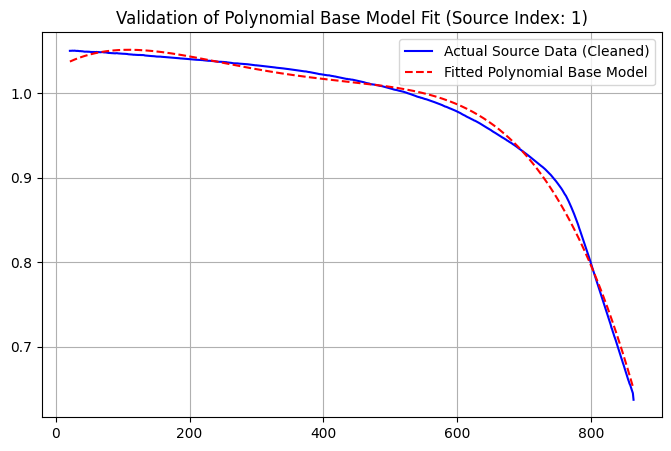


Running MCMC sampler with polynomial base model...


100%|██████████| 5000/5000 [00:10<00:00, 490.94it/s]


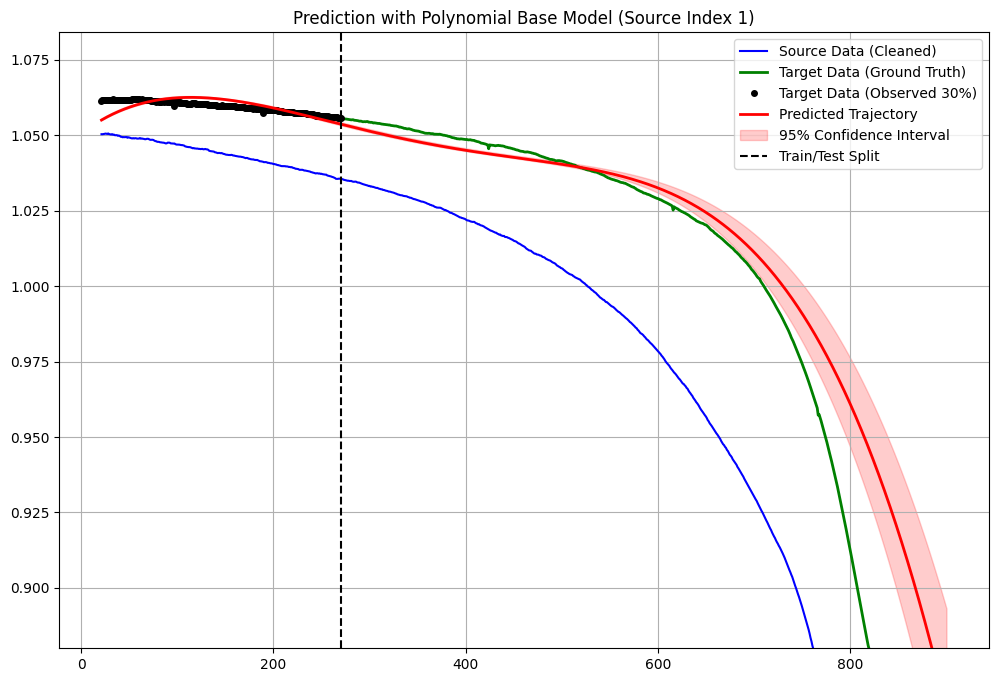


--- Final Trajectory Prediction Performance ---
R²:   0.7512
MAE:  0.0212 Ah
RMSE: 0.0428 Ah
MAPE: 2.5433 %


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import emcee
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Define Helper Function for MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define the polynomial base model
def polynomial_model(x, p):
    """Evaluates a polynomial model. 'p' is a list of coefficients."""
    return np.polyval(p, x)

# Define the transfer model for the polynomial base
def transferred_model_poly(transfer_params, x_new, base_model_poly_params):
    rho0, lambda0, rho1, lambda1 = transfer_params
    x_old = rho0 * x_new + lambda0
    C_old = polynomial_model(x_old, base_model_poly_params)
    C_new = rho1 * C_old + lambda1
    return C_new

# Update the Bayesian probability function to use the polynomial model
def log_probability_poly(params_with_sigma, x_obs, y_obs, base_model_params, predicted_cycle_life, v0):
    rho0, rho1, lambda1, log_sigma = params_with_sigma
    poly_params, x_old_min, source_cycle_life = base_model_params
    x_new_min = x_obs[0]
    lambda0 = x_old_min - rho0 * x_new_min
    
    if not (0.1 < rho0 < 5 and 0.5 < rho1 < 1.5 and -0.5 < lambda1 < 0.5): return -np.inf

    transfer_params = [rho0, lambda0, rho1, lambda1]
    y_pred = transferred_model_poly(transfer_params, x_obs, poly_params)
    sigma = np.exp(log_sigma)
    log_likelihood_val = -0.5 * np.sum(((y_obs - y_pred) / sigma) ** 2) - len(y_obs) * np.log(sigma)
    if not np.isfinite(log_likelihood_val): return -np.inf
        
    mu1 = np.array([1.0, 0.0]); v1 = 0.1
    log_prior_rho1_lambda1 = -0.5 * np.sum(((np.array([rho1, lambda1]) - mu1) / v1) ** 2)
    current_predicted_cycle_life = (source_cycle_life - lambda0) / rho0
    log_prior_cycle_life = -0.5 * ((current_predicted_cycle_life - predicted_cycle_life) / v0) ** 2
    
    return log_likelihood_val + log_prior_rho1_lambda1 + log_prior_cycle_life

# Setup: Choose a source and target 
source_battery_index = 1
target_battery_index = 7
cycles_to_skip = 20

# Data Preparation 
source_battery = batteries_data[source_battery_index]
source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
source_capacity = source_capacity_raw[cycles_to_skip:]; source_cycles = source_cycles_raw[cycles_to_skip:]

target_battery = batteries_test[target_battery_index]
target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
target_capacity_full = target_capacity_full_raw[cycles_to_skip:]; target_cycles_full = target_cycles_full_raw[cycles_to_skip:]
original_split_cycle = target_battery['early_cycle_count']
observed_start_cycle = cycles_to_skip + 1
observed_cycles_full_range = np.arange(observed_start_cycle, original_split_cycle + 1)
start_index_obs = np.where(target_cycles_full_raw == observed_start_cycle)[0][0]
end_index_obs = np.where(target_cycles_full_raw == original_split_cycle)[0][0]
observed_capacity = target_capacity_full_raw[start_index_obs : end_index_obs + 1]

#  1 Train the NEW Polynomial Base Model 
print(f"Fitting 4th-order polynomial base model for source battery {source_battery_index}...")
poly_coeffs = np.polyfit(source_cycles, source_capacity, 4)
print("Polynomial fit finished.")

#  Validate the new base model fit 
plt.figure(figsize=(8, 5))
plt.plot(source_cycles, source_capacity, 'b-', label='Actual Source Data (Cleaned)')
plt.plot(source_cycles, polynomial_model(source_cycles, poly_coeffs), 'r--', label='Fitted Polynomial Base Model')
plt.title(f"Validation of Polynomial Base Model Fit (Source Index: {source_battery_index})")
plt.legend(); plt.grid(True); plt.show()

#  2 Predict Cycle Life
target_vf_sequence = X_test[target_battery_index:target_battery_index+1]
predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]

#  3 Run MCMC Sampler with the NEW Polynomial Model
base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life'])
n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_poly, args=(
    observed_cycles_full_range, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
))
print("\nRunning MCMC sampler with polynomial base model...")
sampler.run_mcmc(p0, n_steps, progress=True)
flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

# 4 Extract Results
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_full_range[0]

#5 Generate Predictions and Visualize 
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles[0] - rho0 * observed_cycles_full_range[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], target_cycles_full, poly_coeffs))
mean_prediction = np.mean(np.array(predictions), axis=0)
lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 8))
plt.plot(source_cycles, source_capacity, 'b-', label='Source Data (Cleaned)')
plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
plt.plot(observed_cycles_full_range, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
plt.axvline(x=original_split_cycle, color='k', linestyle='--', label='Train/Test Split')
plt.title(f"Prediction with Polynomial Base Model (Source Index {source_battery_index})")
plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()


#Final Metrics
test_start_index = np.where(target_cycles_full == original_split_cycle)[0][0]
y_true_test = target_capacity_full[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]


trajectory_r2 = r2_score(y_true_test, y_pred_test)
trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
trajectory_mape = mean_absolute_percentage_error(y_true_test, y_pred_test)

print(f"\n--- Final Trajectory Prediction Performance ---")
print(f"R²:   {trajectory_r2:.4f}")
print(f"MAE:  {trajectory_mae:.4f} Ah")
print(f"RMSE: {trajectory_rmse:.4f} Ah")
print(f"MAPE: {trajectory_mape:.4f} %")


--- Running Test: Source Index 1 -> Target Index 11 ---
Cycle life prediction for target: 1112 cycles (True: 1117)


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:09<00:00, 546.92it/s]


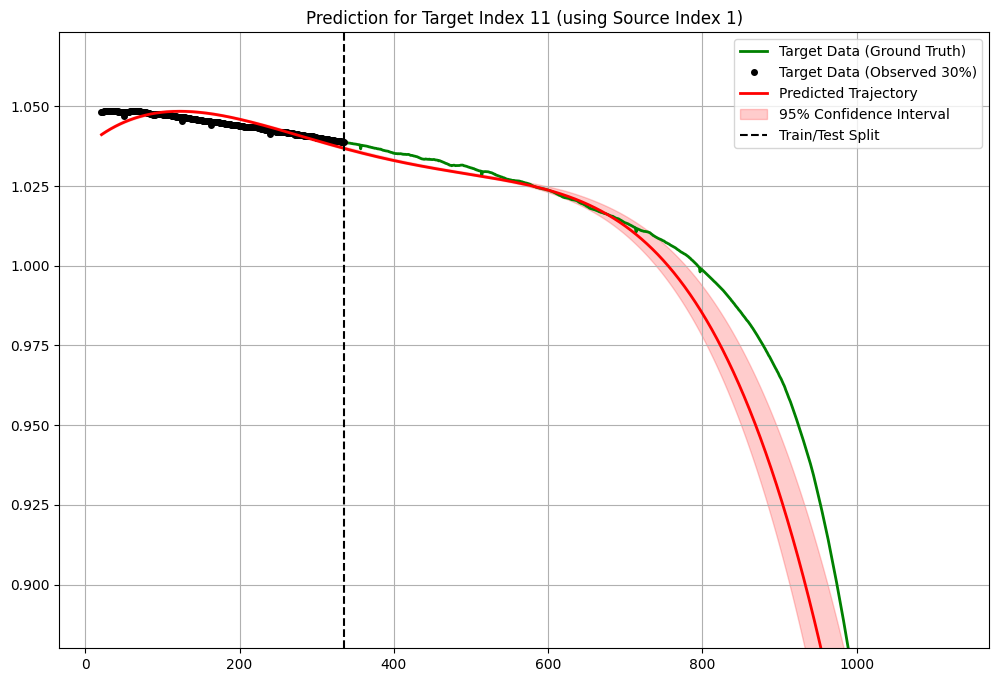


 Final Trajectory Prediction Performance 
R²:   0.9513
MAE:  0.0145 Ah
RMSE: 0.0213 Ah
MAPE: 1.6471 %


In [18]:
run_transfer_learning_test(source_index=1, target_index=11) #maek suure to run the helper function below run_transfer_learning_test()

In [19]:
poly_coeffs

array([-5.08558427e-12,  6.90056873e-09, -3.23641255e-06,  4.86653050e-04,
        1.02879839e+00])

In [17]:
# This cell is a function single function to run the entire test.
# Make sure all previous cells (data loading, Res-CNN training, etc.) have been run.

#Helper Function for MAPE (included again
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Add a small epsilon to the denominator to avoid division by zero
    epsilon = 1e-9
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

def run_transfer_learning_test(source_index, target_index):
    """
    Performs the complete two-stage aging trajectory prediction for a given
    source and target battery.

    Args:
        source_index (int): The index of the battery to use as the source model.
        target_index (int): The index of the battery in the test set to predict.
    """
    print(f"\n{'='*60}\n--- Running Test: Source Index {source_index} -> Target Index {target_index} ---\n{'='*60}")

    #  1 PREPARE BASE MODEL FROM SOURCE 
    source_battery = batteries_data[source_index]
    source_capacity_raw = np.concatenate([source_battery['early_cycles'], source_battery['remaining_cycles']])
    source_cycles_raw = np.arange(1, len(source_capacity_raw) + 1)
    cycles_to_skip = 20
    source_capacity = source_capacity_raw[cycles_to_skip:]
    source_cycles = source_cycles_raw[cycles_to_skip:]
    
    # Fit the robust polynomial base model
    poly_coeffs = np.polyfit(source_cycles, source_capacity, 4)
    
    #  2 PREPARE NEW TARGET DATA 
    target_battery = batteries_test[target_index]
    target_capacity_full_raw = np.concatenate([target_battery['early_cycles'], target_battery['remaining_cycles']])
    target_cycles_full_raw = np.arange(1, len(target_capacity_full_raw) + 1)
    target_capacity_full = target_capacity_full_raw[cycles_to_skip:]
    target_cycles_full = target_cycles_full_raw[cycles_to_skip:]
    
    original_split_cycle = target_battery['early_cycle_count']
    observed_start_cycle = cycles_to_skip + 1
    
    if original_split_cycle <= cycles_to_skip:
        print("ERROR: Observation window is entirely within the skipped period. Cannot test.")
        return

    observed_cycles_full_range = np.arange(observed_start_cycle, original_split_cycle + 1)
    start_index_obs = np.where(target_cycles_full_raw == observed_start_cycle)[0][0]
    end_index_obs = np.where(target_cycles_full_raw == original_split_cycle)[0][0]
    observed_capacity = target_capacity_full_raw[start_index_obs : end_index_obs + 1]

    #  3 PREDICT CYCLE LIFE 
    target_vf_sequence = X_test[target_index:target_index+1]
    predicted_cycle_life = y_scaler.inverse_transform(model(torch.FloatTensor(target_vf_sequence).to(device)).cpu().detach().numpy())[0][0]
    print(f"Cycle life prediction for target: {predicted_cycle_life:.0f} cycles (True: {target_battery['cycle_life']:.0f})")

    #  4 RUN MCMC SAMPLER 
    base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life'])
    n_walkers, n_dim, n_steps, burn_in = 32, 4, 5000, 1000
    initial_state = np.array([1.0, 1.0, 0.0, np.log(0.01)])
    p0 = initial_state + 1e-3 * np.random.randn(n_walkers, n_dim)

    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability_poly, args=(
        observed_cycles_full_range, observed_capacity, base_model_params_full, predicted_cycle_life, std_dev_prediction_error
    ))
    sampler.run_mcmc(p0, n_steps, progress=True)
    flat_samples = sampler.get_chain(discard=burn_in, thin=15, flat=True)

    #  5 VISUALIZE AND EVALUATE 
    map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
    map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_full_range[0]
    
    predictions = []
    for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
        rho0, rho1, lambda1 = p[:-1]
        lambda0 = source_cycles[0] - rho0 * observed_cycles_full_range[0]
        predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], target_cycles_full, poly_coeffs))
    mean_prediction = np.mean(np.array(predictions), axis=0)
    lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

    plt.figure(figsize=(12, 8))
    plt.plot(target_cycles_full, target_capacity_full, 'g-', lw=2, label='Target Data (Ground Truth)')
    plt.plot(observed_cycles_full_range, observed_capacity, 'ko', markersize=4, label='Target Data (Observed 30%)')
    plt.plot(target_cycles_full, mean_prediction, 'r-', lw=2, label='Predicted Trajectory')
    plt.fill_between(target_cycles_full, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
    plt.axvline(x=original_split_cycle, color='k', linestyle='--', label='Train/Test Split')
    plt.title(f"Prediction for Target Index {target_index} (using Source Index {source_index})")
    plt.legend(); plt.grid(True); plt.ylim(bottom=0.88); plt.show()

    test_start_index = np.where(target_cycles_full == original_split_cycle)[0][0]
    y_true_test = target_capacity_full[test_start_index:]
    y_pred_test = mean_prediction[test_start_index:]
    
    # Calculate all four metrics 
    trajectory_r2 = r2_score(y_true_test, y_pred_test)
    trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
    trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    trajectory_mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
    
    print(f"\n Final Trajectory Prediction Performance ")
    print(f"R²:   {trajectory_r2:.4f}")
    print(f"MAE:  {trajectory_mae:.4f} Ah")
    print(f"RMSE: {trajectory_rmse:.4f} Ah")
    print(f"MAPE: {trajectory_mape:.4f} %")




# Testing on NASA Dataset

# Zero-shot transfer learning

In [20]:
# Load Saved Model

# 1. Re-instantiate the model architecture and move it to the device
model = ResCNN().to(device)

# 2. Define the path to the saved model
model_save_path = 'resnet_cycle_predictor.pth'

# 3. Load the saved state dictionary into the model
model.load_state_dict(torch.load(model_save_path))

# 4. Set the model to evaluation mode (important for inference)
model.eval()

print(f"Model loaded successfully from: {model_save_path}")

Model loaded successfully from: resnet_cycle_predictor.pth


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

#

def process_nasa_battery_from_csv(battery_id, data_path):
    """
    Loads charge and discharge CSVs for a battery, extracts VF and cycle life.
    """
    charge_file = data_path / f'{battery_id}_charge.csv'
    discharge_file = data_path / f'{battery_id}_discharge.csv'

    if not charge_file.exists() or not discharge_file.exists():
        return None

    charge_df = pd.read_csv(charge_file)
    discharge_df = pd.read_csv(discharge_file)

    # Get Cycle Life from Discharge Data
    capacity_data = discharge_df[['id_cycle', 'Capacity']].dropna()
    if capacity_data.empty:
        return None
    
    discharge_capacities = capacity_data.groupby('id_cycle')['Capacity'].last().values
    
    nominal_capacity = 2.0
    eol_threshold = nominal_capacity * 0.7
    
    cycle_life_array = np.where(discharge_capacities < eol_threshold)[0]
    cycle_life = cycle_life_array[0] if len(cycle_life_array) > 0 else len(discharge_capacities)

    # Extract Relative VF from Charge Data
    vf_values = {}
    # Set a reachable target capacity based on our previous data inspection
    target_charge_capacity = 1.0

    for cycle_num, cycle_data in charge_df.groupby('id_cycle'):
        if 'Current_charge' in cycle_data.columns:
            charging_phase = cycle_data[cycle_data['Current_measured'] > 0]
            if charging_phase.empty:
                continue

            charge_caps = charging_phase['Current_charge'].values
            voltages = charging_phase['Voltage_measured'].values
            
            if target_charge_capacity <= np.max(charge_caps):
                idx = np.argmin(np.abs(charge_caps - target_charge_capacity))
                vf_values[cycle_num] = voltages[idx]

    if len(vf_values) > 20:
        return {
            'name': battery_id,
            'vf_values': vf_values,
            'cycle_life': cycle_life,
            'discharge_capacities': discharge_capacities
        }
    
    return None

def pad_to_length(array, target_length):
    """Pads or truncates an array to a target length."""
    if len(array) >= target_length:
        return array[:target_length]
    else:
        padding = np.full(target_length - len(array), array[-1] if len(array) > 0 else 0)
        return np.concatenate([array, padding])

In [266]:
battery_ids

['B0005',
 'B0006',
 'B0007',
 'B0018',
 'B0025',
 'B0026',
 'B0027',
 'B0028',
 'B0029',
 'B0030',
 'B0031',
 'B0032',
 'B0033',
 'B0034',
 'B0036',
 'B0038',
 'B0039',
 'B0040',
 'B0041',
 'B0042',
 'B0043',
 'B0044',
 'B0045',
 'B0046',
 'B0047',
 'B0048',
 'B0049',
 'B0051',
 'B0053',
 'B0054',
 'B0055',
 'B0056']

In [609]:
csv_data_path = Path('C:/Users/Zakar/lfp-battery-degradation/data/processed/')

# Find all unique battery IDs
battery_ids = sorted([p.stem.replace('_charge', '') for p in csv_data_path.glob('B*_charge.csv')])

# Process all batteries
processed_nasa_data = []
for battery_id in battery_ids:
    battery_data = process_nasa_battery_from_csv(battery_id, csv_data_path)
    if battery_data:
        processed_nasa_data.append(battery_data)

print(f"Successfully processed {len(processed_nasa_data)} total NASA batteries from CSV files.")

# --- 3. Prepare Data for Res-CNN with Flexible Filtering ---
vf_sequences_list = []
cycle_lives = []
batteries_info = []

# Use a fixed number of early cycles to ensure more batteries are included
num_early_cycles = 5
min_vf_measurements = 1 # Require at least 5 data points in that window

for battery in processed_nasa_data:
    if battery['cycle_life'] < num_early_cycles:
        continue

    early_vf_values = {k: v for k, v in battery['vf_values'].items() if k < num_early_cycles}
    
    if len(early_vf_values) < min_vf_measurements:
        continue

    cycle_indices = np.array(sorted(early_vf_values.keys()))
    vf_vals = np.array([early_vf_values[idx] for idx in cycle_indices])
    
    vf_padded = pad_to_length(vf_vals, 1000)
    cycle_indices_padded = pad_to_length(cycle_indices, 1000)
    
    sequence = np.stack([vf_padded, cycle_indices_padded], axis=1).reshape(1000, 2, 1)
    
    vf_sequences_list.append(sequence)
    cycle_lives.append(battery['cycle_life'])
    batteries_info.append({
        'name': battery['name'],
        'cycle_life': battery['cycle_life'],
        'capacities': battery['discharge_capacities']
    })

# Convert to final numpy arrays
nasa_vf_sequences = np.array(vf_sequences_list)
nasa_cycle_lives = np.array(cycle_lives)

# Save the prepared data to a pickle file
with open('nasa_prepared_for_training.pkl', 'wb') as f:
    pickle.dump({
        'vf_sequences': nasa_vf_sequences,
        'cycle_lives': nasa_cycle_lives,
        'batteries_info': batteries_info
    }, f)

print(f"\nData from {len(batteries_info)} batteries is ready for Stage 1 training.")
print(f"VF sequences shape: {nasa_vf_sequences.shape}")
print(f"Cycle lives shape: {nasa_cycle_lives.shape}")
print("Data saved to 'nasa_prepared_for_training.pkl'")

Successfully processed 32 total NASA batteries from CSV files.

Data from 18 batteries is ready for Stage 1 training.
VF sequences shape: (18, 1000, 2, 1)
Cycle lives shape: (18,)
Data saved to 'nasa_prepared_for_training.pkl'



--- Running Zero-Shot Test on NASA Battery: B0005 ---
Extracted 37 VF data points 
Predicted Cycle Life (using MIT model): -2596 cycles (True: 124)

--- Stage 1 (Cycle Life) Zero-Shot Performance ---
Absolute Error:            2719.52 cycles
Absolute Percentage Error: 2193.16 %


100%|██████████| 5000/5000 [00:08<00:00, 582.60it/s]


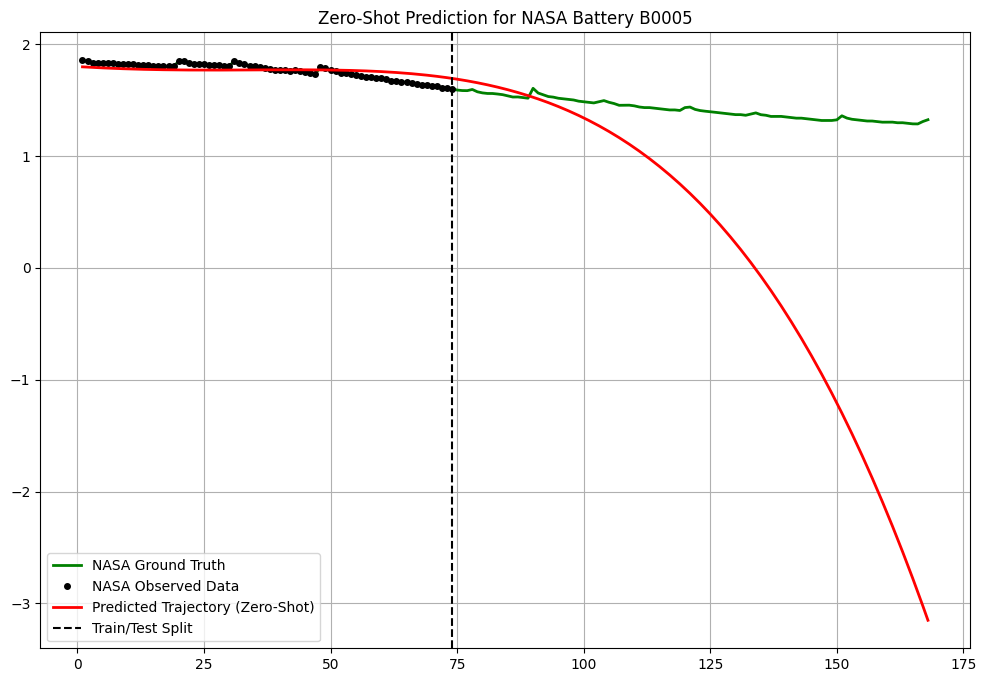


--- Stage 2 (Trajectory) Zero-Shot Performance ---
R²:   -383.2696
MAE:  1.2619 Ah
RMSE: 1.8063 Ah
MAPE: 94.3526 %


In [611]:


def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    epsilon = 1e-9 # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

#   NASA battery to test ---
target_nasa_battery_info = batteries_info[0] # Using the first battery from your processed list
target_nasa_battery_id = target_nasa_battery_info['name']
csv_data_path = Path('C:/Users/Zakar/lfp-battery-degradation/data/processed/')

print(f"\n--- Running Zero-Shot Test on NASA Battery: {target_nasa_battery_id} ---")

#2 LOAD AND PREPARE NASA TARGET DATA 
charge_file = csv_data_path / f'{target_nasa_battery_id}_charge.csv'
discharge_file = csv_data_path / f'{target_nasa_battery_id}_discharge.csv'

if not (charge_file.exists() and discharge_file.exists()):
    print("ERROR: CSV files for the target battery not found.")
else:
    charge_df_nasa = pd.read_csv(charge_file)
    nasa_ground_truth_capacity = target_nasa_battery_info['capacities']
    nasa_ground_truth_cycles = np.arange(1, len(nasa_ground_truth_capacity) + 1)

    # EXTRACT SPECIFIC VF FROM NASA DATA 
    vf_values_nasa = {}
    target_capacity_mit = 1.1

    for cycle_num, cycle_data in charge_df_nasa[charge_df_nasa['id_cycle'] < 100].groupby('id_cycle'):
        if 'Current_charge' in cycle_data.columns:
            charging_phase = cycle_data[cycle_data['Current_measured'] > 0]
            if charging_phase.empty: continue
            
            charge_caps = charging_phase['Current_charge'].values
            voltages = charging_phase['Voltage_measured'].values
            
            if target_capacity_mit <= np.max(charge_caps):
                idx = np.argmin(np.abs(charge_caps - target_capacity_mit))
                vf_values_nasa[cycle_num] = voltages[idx]
    
    print(f"Extracted {len(vf_values_nasa)} VF data points ")

    # PREDICT CYCLE LIFE WITH PRE-TRAINED MIT MODEL 
    cycle_indices_nasa = np.array(sorted(vf_values_nasa.keys()))
    vf_vals_nasa = np.array([vf_values_nasa[idx] for idx in cycle_indices_nasa])
    
    vf_padded_nasa = pad_to_length(vf_vals_nasa, 1000)
    cycle_indices_padded_nasa = pad_to_length(cycle_indices_nasa, 1000)
    sequence_nasa = np.stack([vf_padded_nasa, cycle_indices_padded_nasa], axis=1).reshape(1, 1000, 2, 1)
    
    vf_to_scale = sequence_nasa[:, :, 0, 0]
    cycle_to_scale = sequence_nasa[:, :, 1, 0]
    vf_scaled = vf_scaler.transform(vf_to_scale)
    cycle_scaled = cycle_scaler.transform(cycle_to_scale)
    sequence_nasa[:, :, 0, 0] = vf_scaled
    sequence_nasa[:, :, 1, 0] = cycle_scaled
    
    with torch.no_grad():
        sequence_tensor = torch.FloatTensor(np.transpose(sequence_nasa, (0, 3, 1, 2))).to(device)
        prediction_scaled = model(sequence_tensor)
        predicted_cycle_life_nasa = y_scaler.inverse_transform(prediction_scaled.cpu().numpy())[0][0]

    true_cycle_life_nasa = target_nasa_battery_info['cycle_life']
    print(f"Predicted Cycle Life (using MIT model): {predicted_cycle_life_nasa:.0f} cycles (True: {true_cycle_life_nasa})")

    #   EVALUATE STAGE 1 PERFORMANCE 
    s1_abs_error = abs(true_cycle_life_nasa - predicted_cycle_life_nasa)
    s1_ape = (s1_abs_error / true_cycle_life_nasa) * 100
    print("\n--- Stage 1 (Cycle Life) Zero-Shot Performance ---")
    print(f"Absolute Error:            {s1_abs_error:.2f} cycles")
    print(f"Absolute Percentage Error: {s1_ape:.2f} %")

    # 5 PREDICT TRAJECTORY WITH PRE-TRAINED MIT BASE MODEL
    nasa_split_cycle = int(0.6 * target_nasa_battery_info['cycle_life'])
    observed_mask_nasa = nasa_ground_truth_cycles <= nasa_split_cycle
    observed_cycles_nasa = nasa_ground_truth_cycles[observed_mask_nasa]
    observed_capacity_nasa = nasa_ground_truth_capacity[observed_mask_nasa]

    base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life']) 
    sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
        observed_cycles_nasa, observed_capacity_nasa, base_model_params_full, predicted_cycle_life_nasa, std_dev_prediction_error
    ))
    p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
    sampler.run_mcmc(p0, 5000, progress=True)
    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
    
    #  6 VISUALIZE AND EVALUATE 
    map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
    map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_nasa[0]
    
    predictions = []
    for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
        rho0, rho1, lambda1 = p[:-1]
        lambda0 = source_cycles[0] - rho0 * observed_cycles_nasa[0]
        predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], nasa_ground_truth_cycles, poly_coeffs))
    mean_prediction = np.mean(np.array(predictions), axis=0)
    
    plt.figure(figsize=(12, 8))
    plt.plot(nasa_ground_truth_cycles, nasa_ground_truth_capacity, 'g-', lw=2, label='NASA Ground Truth')
    plt.plot(observed_cycles_nasa, observed_capacity_nasa, 'ko', markersize=4, label='NASA Observed Data')
    plt.plot(nasa_ground_truth_cycles, mean_prediction, 'r-', lw=2, label='Predicted Trajectory (Zero-Shot)')
    plt.axvline(x=nasa_split_cycle, color='k', linestyle='--', label='Train/Test Split')
    plt.title(f"Zero-Shot Prediction for NASA Battery {target_nasa_battery_id}")
    plt.legend(); plt.grid(True); plt.show()

    test_start_index = len(observed_cycles_nasa)
    y_true_test = nasa_ground_truth_capacity[test_start_index:]
    y_pred_test = mean_prediction[test_start_index:]
    
    #  6a. EVALUATE STAGE 2 PERFORMANCE ---
    trajectory_r2 = r2_score(y_true_test, y_pred_test)
    trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)
    trajectory_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
    trajectory_mape = mean_absolute_percentage_error(y_true_test, y_pred_test)
    
    print(f"\n--- Stage 2 (Trajectory) Zero-Shot Performance ---")
    print(f"R²:   {trajectory_r2:.4f}")
    print(f"MAE:  {trajectory_mae:.4f} Ah")
    print(f"RMSE: {trajectory_rmse:.4f} Ah")
    print(f"MAPE: {trajectory_mape:.4f} %")

# few-shot transfer learning

In [ ]:
# Prepare Few-Shot Data
import pickle
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Load the prepared NASA data from the pickle file
with open('nasa_prepared_for_training.pkl', 'rb') as f:
    nasa_dataset = pickle.load(f)

vf_sequences = nasa_dataset['vf_sequences']
cycle_lives = nasa_dataset['cycle_lives']
batteries_info = nasa_dataset['batteries_info']

# Reshape data
X = np.transpose(vf_sequences, (0, 3, 1, 2))
y = cycle_lives.reshape(-1, 1)

# Split the 11 batteries into a small fine-tuning set and a larger test set
# Using 4 batteries (approx. 30%) for fine-tuning.
X_finetune, X_test_nasa, y_finetune, y_test_nasa, batteries_train_nasa, batteries_test_nasa = train_test_split(
    X, y, batteries_info, test_size=6, random_state=42
)

print(f"Data prepared for few-shot learning:")
print(f"Fine-tuning set size: {len(X_finetune)}")
print(f"Test set size: {len(X_test_nasa)}")

# Normalize the data (fitting on the small fine-tune set)
vf_scaler_nasa = StandardScaler()
X_finetune[:, 0, :, 0] = vf_scaler_nasa.fit_transform(X_finetune[:, 0, :, 0])
X_test_nasa[:, 0, :, 0] = vf_scaler_nasa.transform(X_test_nasa[:, 0, :, 0])

cycle_scaler_nasa = StandardScaler()
X_finetune[:, 0, :, 1] = cycle_scaler_nasa.fit_transform(X_finetune[:, 0, :, 1])
X_test_nasa[:, 0, :, 1] = cycle_scaler_nasa.transform(X_test_nasa[:, 0, :, 1])

y_scaler_nasa = StandardScaler()
y_finetune_scaled = y_scaler_nasa.fit_transform(y_finetune)
y_test_nasa_scaled = y_scaler_nasa.transform(y_test_nasa)

# Create a DataLoader for fine-tuning
finetune_dataset = TensorDataset(torch.FloatTensor(X_finetune), torch.FloatTensor(y_finetune_scaled))
finetune_loader = DataLoader(finetune_dataset, batch_size=4, shuffle=True)

Data prepared for few-shot learning:
Fine-tuning set size: 12
Test set size: 6


In [288]:
X_test_nasa.shape

(14, 1, 1000, 2)

In [290]:
X_finetune

array([[[[-0.15327761, -0.42257713],
         [ 0.62958541,  1.18444612],
         [ 0.61457908,  1.03509834],
         ...,
         [ 0.61457908,  1.03509834],
         [ 0.61457908,  1.03509834],
         [ 0.61457908,  1.03509834]]],


       [[[-0.34818596, -0.42257713],
         [-0.32279137,  1.18444612],
         [-0.32875267,  1.03509834],
         ...,
         [-0.32875267,  1.03509834],
         [-0.32875267,  1.03509834],
         [-0.32875267,  1.03509834]]],


       [[[-0.07269358, -1.69030851],
         [ 0.99335629, -0.90575292],
         [ 1.11029943,  1.03509834],
         ...,
         [ 1.11029943,  1.03509834],
         [ 1.11029943,  1.03509834],
         [ 1.11029943,  1.03509834]]],


       ...,


       [[[-0.38028974,  0.84515425],
         [-0.43052162, -0.90575292],
         [-0.43545977, -1.03509834],
         ...,
         [-0.43545977, -1.03509834],
         [-0.43545977, -1.03509834],
         [-0.43545977, -1.03509834]]],


       [[[-0.11919696,  0.

In [265]:
batteries_train_nasa

[{'name': 'B0047',
  'cycle_life': 9,
  'capacities': array([1.67430474, 1.52436621, 1.5080763 , 1.4835578 , 1.46713917,
         1.44885816, 1.44585342, 1.43111827, 1.41927455, 1.39999742,
         1.38851567, 1.36522347, 1.40604423, 1.40575416, 1.38676629,
         1.37050531, 1.34974311, 1.32515334, 1.31119439, 0.        ,
         1.33942344, 1.28491571, 1.28171916, 1.26000516, 1.26607039,
         1.24135903, 1.22988737, 1.22808861, 1.21398572, 1.21734351,
         1.20734459, 1.18804049, 1.18630475, 1.26139355, 1.26482462,
         1.24664945, 1.23339242, 1.21292501, 1.19991066, 1.1902559 ,
         1.18925638, 1.16706969, 1.16153484, 1.15555638, 1.14885247,
         1.14357299, 1.14180154, 1.13605865, 1.12363647, 1.13204989,
         1.11701018, 1.12004304, 1.10597734, 0.        , 1.19079024,
         1.20123871, 1.19069095, 1.17643757, 1.16281104, 1.15161528,
         1.15836735, 1.16922853, 1.15881485, 1.14395881, 1.13839411,
         0.        , 1.22131029, 1.2031063 , 1.1897

In [ ]:
# Fine-Tune the Model
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1 Instantiate the model architecture
finetuned_model = ResCNN().to(device)

# 2 Load the weights from the model trained on the MIT dataset
mit_model_path = 'resnet_cycle_predictor.pth'
finetuned_model.load_state_dict(torch.load(mit_model_path))
print(f"Loaded pre-trained weights from {mit_model_path}")

# 3 Fine-tune the model on the small NASA set
optimizer = optim.AdamW(finetuned_model.parameters(), lr=1e-3, weight_decay=0.0001) # Use a lower learning rate
criterion = nn.MSELoss()
epochs = 100

print("Starting fine-tuning on NASA data...")
finetuned_model.train()
for epoch in range(epochs):
    for inputs, labels in finetune_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = finetuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Save the newly fine-tuned model
nasa_finetuned_path = 'resnet_nasa_finetuned.pth'
torch.save(finetuned_model.state_dict(), nasa_finetuned_path)
print(f"\nFine-tuning finished. Model saved to: {nasa_finetuned_path}")

Loaded pre-trained weights from resnet_cycle_predictor.pth
Starting fine-tuning on NASA data...

Fine-tuning finished. Model saved to: resnet_nasa_finetuned.pth



--- Stage 1 (Cycle Life) Few-Shot Performance on NASA Test Set ---
R²:   0.4102
MAE:  31.04 cycles
RMSE: 37.22 cycles
MAPE: 157.44 %


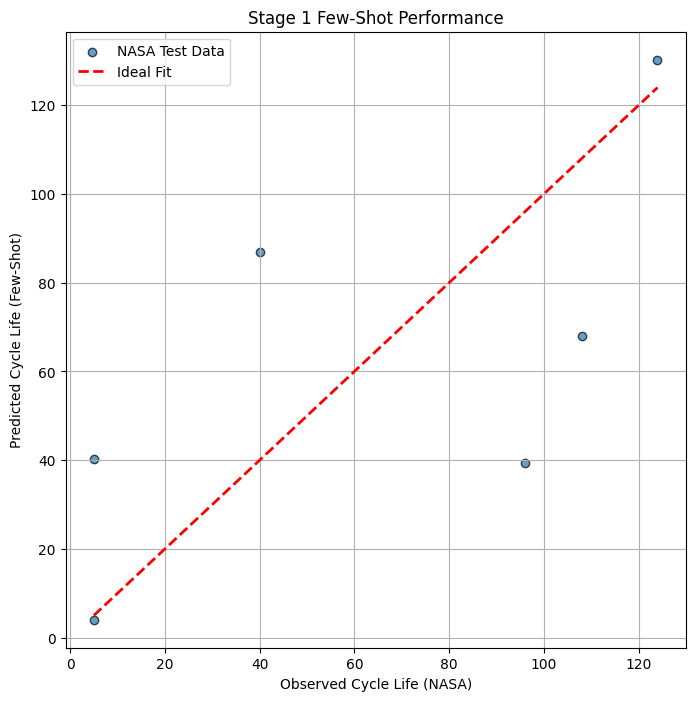

In [ ]:
# Evaluate the Fine-Tuned Stage 1 Model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load the fine-tuned model for evaluation
finetuned_model.load_state_dict(torch.load(nasa_finetuned_path))
finetuned_model.eval()

# Prepare the test data
X_test_tensor = torch.FloatTensor(X_test_nasa).to(device)
y_test_scaled_tensor = torch.FloatTensor(y_test_nasa_scaled).to(device)

# Predict on the NASA test set
with torch.no_grad():
    predictions_scaled = finetuned_model(X_test_tensor)

# Inverse transform to get actual cycle life values
y_pred_finetuned = y_scaler_nasa.inverse_transform(predictions_scaled.cpu().numpy())
y_true_nasa = y_test_nasa

# Calculate performance metrics
s1_r2 = r2_score(y_true_nasa, y_pred_finetuned)
s1_mae = mean_absolute_error(y_true_nasa, y_pred_finetuned)
s1_rmse = np.sqrt(mean_squared_error(y_true_nasa, y_pred_finetuned))
s1_mape = mean_absolute_percentage_error(y_true_nasa, y_pred_finetuned)


print(f"\n--- Stage 1 (Cycle Life) Few-Shot Performance on NASA Test Set ---")
print(f"R²:   {s1_r2:.4f}")
print(f"MAE:  {s1_mae:.2f} cycles")
print(f"RMSE: {s1_rmse:.2f} cycles")
print(f"MAPE: {s1_mape:.2f} %")


# Visualize results
plt.figure(figsize=(8, 8))
plt.scatter(y_true_nasa, y_pred_finetuned, alpha=0.7, edgecolors='k', label='NASA Test Data')
plt.plot([y_true_nasa.min(), y_true_nasa.max()], [y_true_nasa.min(), y_true_nasa.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Observed Cycle Life (NASA)")
plt.ylabel("Predicted Cycle Life (Few-Shot)")
plt.title("Stage 1 Few-Shot Performance")
plt.legend(); plt.grid(True); plt.show()

Successfully created a new polynomial base model from the NASA set.


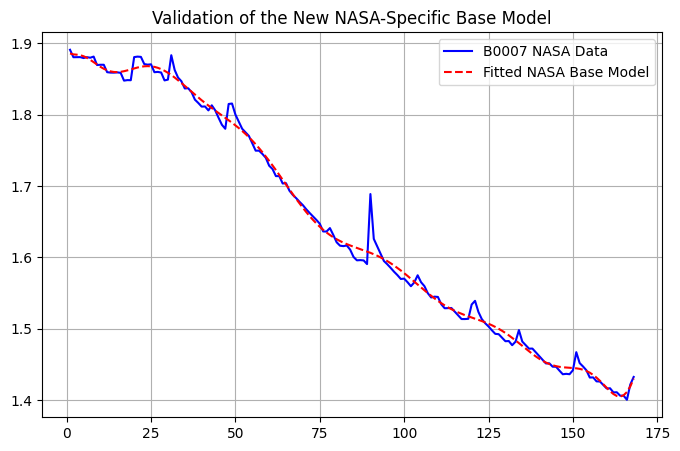

In [ ]:
# Create the NASA-Specific Base Model

# --- 1. Select the batteries from our fine-tuning set to create the new base model ---
# base_model_batteries_info = batteries_train_nasa
base_model_battery = next(b for b in batteries_train_nasa if b['name'] == 'B0007')

# # --- 2. Align and Average the Degradation Curves ---
# min_length = min([len(b['capacities']) for b in base_model_batteries_info])
# aligned_capacities = [b['capacities'][:min_length] for b in base_model_batteries_info]

# average_capacities = np.mean(aligned_capacities, axis=0)
# average_cycles = np.arange(1, len(average_capacities) + 1)

b0007_capacities = base_model_battery['capacities']
b0007_cycles = np.arange(1, len(b0007_capacities) + 1)

# Fit a Polynomial to the Averaged Curve or just one battery with around 168 cyvles
#nasa_poly_coeffs = np.polyfit(average_cycles, average_capacities, 4)
nasa_poly_coeffs = np.polyfit(b0007_cycles, b0007_capacities, 15) # -> this coould lead to overfitting

print("Successfully created a new polynomial base model from the NASA set.")

# --- 4. Visualize the New Base Model Fit ---
plt.figure(figsize=(8, 5))
plt.plot(b0007_cycles, b0007_capacities, 'b-', label='B0007 NASA Data')
plt.plot(b0007_cycles, polynomial_model(b0007_cycles, nasa_poly_coeffs), 'r--', label='Fitted NASA Base Model')
plt.title("Validation of the New NASA-Specific Base Model")
plt.legend(); plt.grid(True); plt.show()

In [197]:
target_battery_info

{'name': 'B0005',
 'cycle_life': 124,
 'capacities': array([1.85648742, 1.84632725, 1.83534919, 1.83526253, 1.83464551,
        1.83566166, 1.83514614, 1.82575679, 1.82477385, 1.82461327,
        1.82461955, 1.81420194, 1.81375216, 1.81344049, 1.802598  ,
        1.8021069 , 1.8025795 , 1.80306831, 1.80277762, 1.84702599,
        1.84741731, 1.83617742, 1.82578075, 1.82511364, 1.8255815 ,
        1.81403113, 1.81476919, 1.81396939, 1.80276567, 1.80407704,
        1.85180255, 1.83070385, 1.81990411, 1.80930796, 1.8046099 ,
        1.79937707, 1.78844323, 1.78292305, 1.77303372, 1.77303776,
        1.76787211, 1.76231507, 1.76761729, 1.76266836, 1.75173049,
        1.7418496 , 1.73609135, 1.79362401, 1.78318902, 1.76736421,
        1.75701779, 1.74687062, 1.74171725, 1.73642251, 1.72632172,
        1.71580654, 1.71053335, 1.7060145 , 1.70031103, 1.69457986,
        1.68490291, 1.67447416, 1.67456925, 1.66371638, 1.65901387,
        1.65385406, 1.64265378, 1.63785784, 1.63273504, 1.627752

--- Running Stage 2 Few-Shot Test on: B0005 ---
Using Predicted Cycle Life: 130 (True: 124)


100%|██████████| 5000/5000 [00:13<00:00, 381.05it/s]


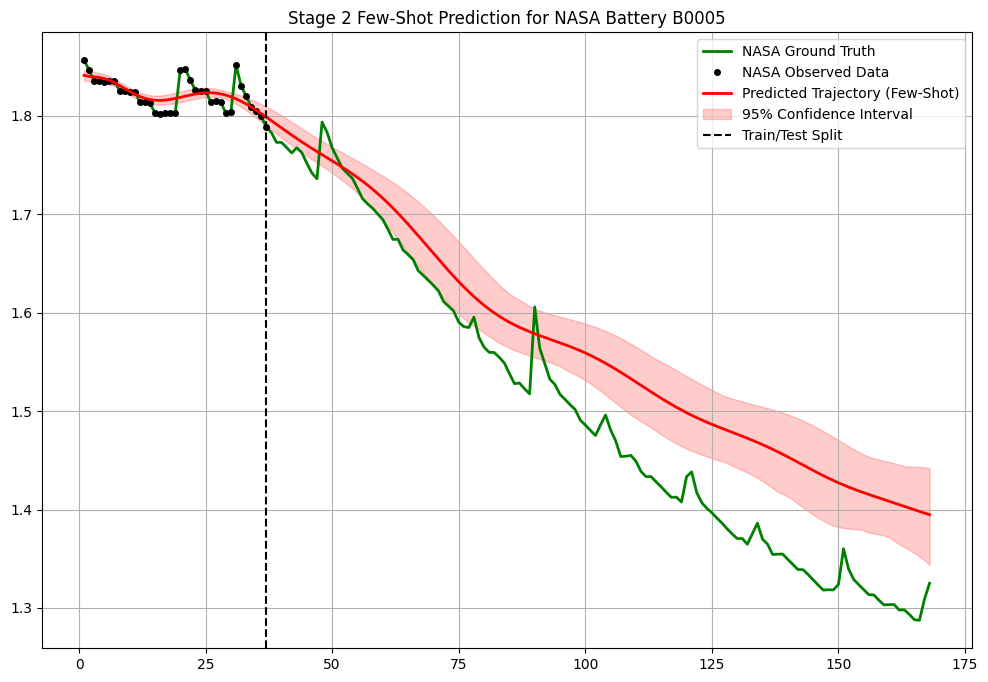


--- Few-Shot Trajectory Performance ---
R²:   0.7765
MAE:  0.0640 Ah


In [ ]:
# Run the Final "Few-Shot" Test for Stage 2

# --- 1. CONFIGURATION: Choose a battery from the NASA test set to evaluate ---
# Index from 0 to 6
target_index_in_test_set = 0

# --- 2. RETRIEVE DATA ---
target_battery_info = batteries_test_nasa[target_index_in_test_set]
# Get the corresponding cycle life prediction from our previous evaluation
predicted_cycle_life_nasa = y_pred_finetuned[target_index_in_test_set][0]
true_cycle_life_nasa = target_battery_info['cycle_life']

print(f"--- Running Stage 2 Few-Shot Test on: {target_battery_info['name']} ---")
print(f"Using Predicted Cycle Life: {predicted_cycle_life_nasa:.0f} (True: {true_cycle_life_nasa})")

# --- 3. PREDICT TRAJECTORY (STAGE 2 FEW-SHOT) ---
# Prepare the data for this specific target battery
nasa_ground_truth_capacity = target_battery_info['capacities']
nasa_ground_truth_cycles = np.arange(1, len(nasa_ground_truth_capacity) + 1)
nasa_split_cycle = int(0.3 * true_cycle_life_nasa)
observed_mask_nasa = nasa_ground_truth_cycles <= nasa_split_cycle
observed_cycles_nasa = nasa_ground_truth_cycles[observed_mask_nasa]
observed_capacity_nasa = nasa_ground_truth_capacity[observed_mask_nasa]

# MCMC using the NEW NASA polynomial model
# Calculate the average life of the batteries used for the base model
avg_source_life = np.mean([b['cycle_life'] for b in base_model_batteries_info])
base_model_params_full = (nasa_poly_coeffs, average_cycles[0], avg_source_life)
# Calculate the standard deviation of the fine-tuned model's errors for the prior
std_dev_prediction_error_nasa = np.std(y_true_nasa - y_pred_finetuned)

sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
    observed_cycles_nasa, observed_capacity_nasa, base_model_params_full, predicted_cycle_life_nasa, std_dev_prediction_error_nasa
))
p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
sampler.run_mcmc(p0, 5000, progress=True)
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# --- 4. VISUALIZE AND EVALUATE ---
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = average_cycles[0] - map_rho0 * observed_cycles_nasa[0]

predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = average_cycles[0] - rho0 * observed_cycles_nasa[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], nasa_ground_truth_cycles, nasa_poly_coeffs))
mean_prediction = np.mean(np.array(predictions), axis=0)
lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)


plt.figure(figsize=(12, 8))
plt.plot(nasa_ground_truth_cycles, nasa_ground_truth_capacity, 'g-', lw=2, label='NASA Ground Truth')
plt.plot(observed_cycles_nasa, observed_capacity_nasa, 'ko', markersize=4, label='NASA Observed Data')
plt.plot(nasa_ground_truth_cycles, mean_prediction, 'r-', lw=2, label='Predicted Trajectory (Few-Shot)')
plt.fill_between(nasa_ground_truth_cycles, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
plt.axvline(x=nasa_split_cycle, color='k', linestyle='--', label='Train/Test Split')
plt.title(f"Stage 2 Few-Shot Prediction for NASA Battery {target_battery_info['name']}")
plt.legend(); plt.grid(True); plt.show()

# Calculate final metrics
test_start_index = len(observed_cycles_nasa)
y_true_test = nasa_ground_truth_capacity[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]
trajectory_r2 = r2_score(y_true_test, y_pred_test)
trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)

print(f"\n--- Few-Shot Trajectory Performance ---")
print(f"R²:   {trajectory_r2:.4f}")
print(f"MAE:  {trajectory_mae:.4f} Ah")

In [690]:
# Inspection
print(" Inspecting Processed Battery Data")
print(f"{'Battery Name'} | {'Cycle Life'} | {'30% Limit'} | {'VF Count'} | {'Result'}")

included_count = 0
for battery in processed_nasa_data:
    cycle_life = battery['cycle_life']
    early_cycle_limit = int(0.3 * cycle_life)
    
    early_vf_values = {k: v for k, v in battery['vf_values'].items() if k < early_cycle_limit}
    vf_count = len(early_vf_values)
    
    result = "INCLUDE" if vf_count >= 10 else "EXCLUDE"
    if result == "INCLUDE":
        included_count += 1

    print(f"{battery['name']:<10} | {cycle_life:<12} | {early_cycle_limit:<10} | {vf_count:<10} | {result}")

print(f"\nTotal batteries included: {included_count}")

 Inspecting Processed Battery Data
Battery Name | Cycle Life | 30% Limit | VF Count | Result
B0005      | 124          | 37         | 19         | INCLUDE
B0006      | 108          | 32         | 17         | INCLUDE
B0007      | 168          | 50         | 23         | INCLUDE
B0018      | 96           | 28         | 9          | EXCLUDE
B0025      | 28           | 8          | 3          | EXCLUDE
B0026      | 5            | 1          | 0          | EXCLUDE
B0027      | 28           | 8          | 3          | EXCLUDE
B0028      | 28           | 8          | 3          | EXCLUDE
B0029      | 40           | 12         | 5          | EXCLUDE
B0030      | 40           | 12         | 5          | EXCLUDE
B0031      | 40           | 12         | 5          | EXCLUDE
B0032      | 40           | 12         | 5          | EXCLUDE
B0033      | 0            | 0          | 0          | EXCLUDE
B0034      | 0            | 0          | 0          | EXCLUDE
B0036      | 0            | 0          

# Testing on CS Dataset
# Zero-shot transfer learning

In [691]:
import pandas as pd
from pathlib import Path

csv_data_path = Path('C:/Users/Zakar/lfp-battery-degradation/data/processed/')

# Choose a sample battery ID to inspect
battery_id_to_inspect = 'CS2_33'

charge_file = csv_data_path / f'{battery_id_to_inspect}_charge.csv'
discharge_file = csv_data_path / f'{battery_id_to_inspect}_discharge.csv'

print(f"--- Inspecting CSV Data for Battery: {battery_id_to_inspect} ---")

#  Inspect the Charge Data 
if charge_file.exists():
    charge_df = pd.read_csv(charge_file)
    print("\n--- Charge Data Structure (`_charge.csv`) ---")
    charge_df.info()
    
    print("\n--- Charge Data Head (First 5 Rows) ---")
    display(charge_df.head())
else:
    print(f"\nCharge file not found: {charge_file}")

#  Inspect the Discharge Data 
if discharge_file.exists():
    discharge_df = pd.read_csv(discharge_file)
    print("\n\n--- Discharge Data Structure (`_discharge.csv`) ---")
    discharge_df.info()
    
    print("\n--- Discharge Data Head (First 5 Rows) ---")
    display(discharge_df.head())
else:
    print(f"\nDischarge file not found: {discharge_file}")

--- Inspecting CSV Data for Battery: CS2_33 ---

--- Charge Data Structure (`_charge.csv`) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152620 entries, 0 to 152619
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Time                  152620 non-null  float64
 1   Voltage_measured      152620 non-null  float64
 2   Current_measured      152620 non-null  float64
 3   Temperature_measured  152620 non-null  float64
 4   Capacity              152620 non-null  float64
 5   id_cycle              152620 non-null  int64  
 6   battery_name          152620 non-null  object 
dtypes: float64(5), int64(1), object(1)
memory usage: 8.2+ MB

--- Charge Data Head (First 5 Rows) ---


,Time,Voltage_measured,Current_measured,Temperature_measured,Capacity,id_cycle,battery_name
0,130.028912,3.494267,0.550025,25.0,1.161693,1,CS2_33_8_17_10
1,140.042404,3.516946,0.549845,25.0,1.161693,1,CS2_33_8_17_10
2,150.057992,3.536709,0.549665,25.0,1.161693,1,CS2_33_8_17_10
3,160.073342,3.554366,0.549665,25.0,1.161693,1,CS2_33_8_17_10
4,170.088840,3.570566,0.550025,25.0,1.161693,1,CS2_33_8_17_10




--- Discharge Data Structure (`_discharge.csv`) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162163 entries, 0 to 162162
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Time                  162163 non-null  float64
 1   Voltage_measured      162163 non-null  float64
 2   Current_measured      162163 non-null  float64
 3   Temperature_measured  162163 non-null  float64
 4   Capacity              162163 non-null  float64
 5   id_cycle              162163 non-null  int64  
 6   battery_name          162163 non-null  object 
dtypes: float64(5), int64(1), object(1)
memory usage: 8.7+ MB

--- Discharge Data Head (First 5 Rows) ---


,Time,Voltage_measured,Current_measured,Temperature_measured,Capacity,id_cycle,battery_name
0,9367.265944,4.192937,-0.001154,25.0,1.161693,1,CS2_33_8_17_10
1,9377.281517,4.118745,-0.550173,25.0,1.161693,1,CS2_33_8_17_10
2,9387.297101,4.111132,-0.550173,25.0,1.161693,1,CS2_33_8_17_10
3,9397.312576,4.104814,-0.550173,25.0,1.161693,1,CS2_33_8_17_10
4,9407.328060,4.099630,-0.550173,25.0,1.161693,1,CS2_33_8_17_10


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle


def process_new_battery_from_csv(battery_id, data_path):
    """
    Loads charge and discharge CSVs for a battery, extracts VF and cycle life
    using the correct column names from the inspection.
    """
    charge_file = data_path / f'{battery_id}_charge.csv'
    discharge_file = data_path / f'{battery_id}_discharge.csv'

    if not charge_file.exists() or not discharge_file.exists():
        return None

    try:
        charge_df = pd.read_csv(charge_file)
        discharge_df = pd.read_csv(discharge_file)

        # Get Cycle Life from Discharge Dat
        # The 'Capacity' column in the discharge file is the battery's health
        capacity_data = discharge_df[['id_cycle', 'Capacity']].dropna()
        if capacity_data.empty:
            return None
        
        # Take the last recorded capacity for each cycle as the official value
        discharge_capacities = capacity_data.groupby('id_cycle')['Capacity'].last().values
        
        if len(discharge_capacities) < 30: # Filter out very short-lived batteries
            return None

        initial_capacity = discharge_capacities[0]
        eol_threshold = initial_capacity * 0.80 # 80% EOL threshold
        
        cycle_life_array = np.where(discharge_capacities < eol_threshold)[0]
        cycle_life = cycle_life_array[0] if len(cycle_life_array) > 0 else len(discharge_capacities)

        #  Extract Relative VF from Charge Data 
        vf_values = {}
        # Use a relative target (e.g., 50% of initial capacity)
        target_charge_capacity = initial_capacity * 0.5

        # Group charge data by cycle
        for cycle_num, cycle_data in charge_df.groupby('id_cycle'):
            # The charging capacity is in the 'Capacity' column of the charge file
            if 'Capacity' in cycle_data.columns and 'Voltage_measured' in cycle_data.columns:
                charge_caps = cycle_data['Capacity'].values
                voltages = cycle_data['Voltage_measured'].values
                
                if target_charge_capacity <= np.max(charge_caps):
                    # Find the voltage at the target charge capacity
                    idx = np.argmin(np.abs(charge_caps - target_charge_capacity))
                    vf_values[cycle_num] = voltages[idx]

        if len(vf_values) > 10:
            return {
                'name': battery_id,
                'vf_values': vf_values,
                'cycle_life': cycle_life,
                'capacities': discharge_capacities
            }
    except Exception:
        return None
    
    return None

def pad_to_length(array, target_length):
    """Pads or truncates an array to a target length."""
    if len(array) >= target_length:
        return array[:target_length]
    else:
        padding = np.full(target_length - len(array), array[-1] if len(array) > 0 else 0)
        return np.concatenate([array, padding])




In [344]:
#battery_data

In [ ]:
csv_data_path = Path('C:/Users/Zakar/lfp-battery-degradation/data/processed/')

# Find all unique battery IDs from the charge files (e.g., 'CS2_33', etc.)
battery_ids = sorted([p.stem.replace('_charge', '') for p in csv_data_path.glob('CS2_*_charge.csv')])
print(f"Found {len(battery_ids)} CS2 battery datasets to process.")

# Process all batteries
processed_new_data = []
for battery_id in battery_ids:
    battery_data = process_new_battery_from_csv(battery_id, csv_data_path)
    if battery_data:
        processed_new_data.append(battery_data)

print(f"Successfully processed {len(processed_new_data)} batteries from the new CSV dataset.")

#  Prepare Data for Res-CNN Model 
vf_sequences_list, cycle_lives, batteries_info = [], [], []

for battery in processed_new_data:
    early_cycle_limit = int(0.3 * battery['cycle_life'])
    early_vf_values = {k: v for k, v in battery['vf_values'].items() if k < early_cycle_limit}
    
    if len(early_vf_values) < 10:
        continue

    cycle_indices = np.array(sorted(early_vf_values.keys()))
    vf_vals = np.array([early_vf_values[idx] for idx in cycle_indices])
    
    vf_padded = pad_to_length(vf_vals, 1000)
    cycle_indices_padded = pad_to_length(cycle_indices, 1000)
    
    sequence = np.stack([vf_padded, cycle_indices_padded], axis=1).reshape(1000, 2, 1)
    
    vf_sequences_list.append(sequence)
    cycle_lives.append(battery['cycle_life'])
    batteries_info.append(battery)

new_vf_sequences = np.array(vf_sequences_list)
new_cycle_lives = np.array(cycle_lives)

# Save the prepared data to a new pickle file
with open('new_dataset_prepared.pkl', 'wb') as f:
    pickle.dump({
        'vf_sequences': new_vf_sequences,
        'cycle_lives': new_cycle_lives,
        'batteries_info': batteries_info
    }, f)

print(f"\nData from {len(batteries_info)} batteries is ready for Stage 1 training.")
print(f"VF sequences shape: {new_vf_sequences.shape}")
print(f"Cycle lives shape: {new_cycle_lives.shape}")
print("Data saved to 'new_dataset_prepared.pkl'")

Found 8 CS2 battery datasets to process.
Successfully processed 7 batteries from the new CSV dataset.

Data from 6 batteries is ready for Stage 1 training.
VF sequences shape: (6, 1000, 2, 1)
Cycle lives shape: (6,)
Data saved to 'new_dataset_prepared.pkl'


In [ ]:
# Zero-Shot Evaluation on the New Dataset (Stage 1)
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  1 Load the prepared new data 
with open('new_dataset_prepared.pkl', 'rb') as f:
    new_dataset = pickle.load(f)

vf_sequences = new_dataset['vf_sequences']
cycle_lives = new_dataset['cycle_lives']
batteries_info_new = new_dataset['batteries_info'] 

#  2 Split the new data into a train/test set 
X_train_new, X_test_new, y_train_new, y_test_new, info_train, info_test = train_test_split(
    vf_sequences, cycle_lives, batteries_info_new, test_size=0.3, random_state=42
)

print(f"New dataset split into {len(X_train_new)} training/fine-tuning samples and {len(X_test_new)} test samples.")

#  3 Predict Cycle Life for each battery in the new test set 
predictions_list_zeroshot = []
true_values_list = []

model.eval()

with torch.no_grad():
    for i in range(len(X_test_new)):
        sequence_new = X_test_new[i:i+1]
        true_cycle_life = y_test_new[i]
        
        sequence_tensor = torch.FloatTensor(np.transpose(sequence_new, (0, 3, 1, 2))).to(device)
        prediction_scaled = model(sequence_tensor)
        predicted_cycle_life = y_scaler.inverse_transform(prediction_scaled.cpu().numpy())[0][0]
        
        predictions_list_zeroshot.append(predicted_cycle_life)
        true_values_list.append(true_cycle_life)

#  4 Calculate and Print Stage 1 Zero-Shot Metrics 
y_pred_zeroshot = np.array(predictions_list_zeroshot)
y_true_new_test = np.array(true_values_list)

s1_r2_zero = r2_score(y_true_new_test, y_pred_zeroshot)
s1_mae_zero = mean_absolute_error(y_true_new_test, y_pred_zeroshot)

print(f"\n--- Stage 1 (Cycle Life) ZERO-SHOT Performance on New Dataset ---")
print(f"R²:   {s1_r2_zero:.4f}")
print(f"MAE:  {s1_mae_zero:.2f} cycles")

New dataset split into 4 training/fine-tuning samples and 2 test samples.

--- Stage 1 (Cycle Life) ZERO-SHOT Performance on New Dataset ---
R²:   -289998.2500
MAE:  1076.99 cycles


Running Stage 2 ZERO-SHOT Test on: CS2_34 ---
Using Predicted Cycle Life: 1157 (True: 89)


100%|██████████| 5000/5000 [00:09<00:00, 503.20it/s]


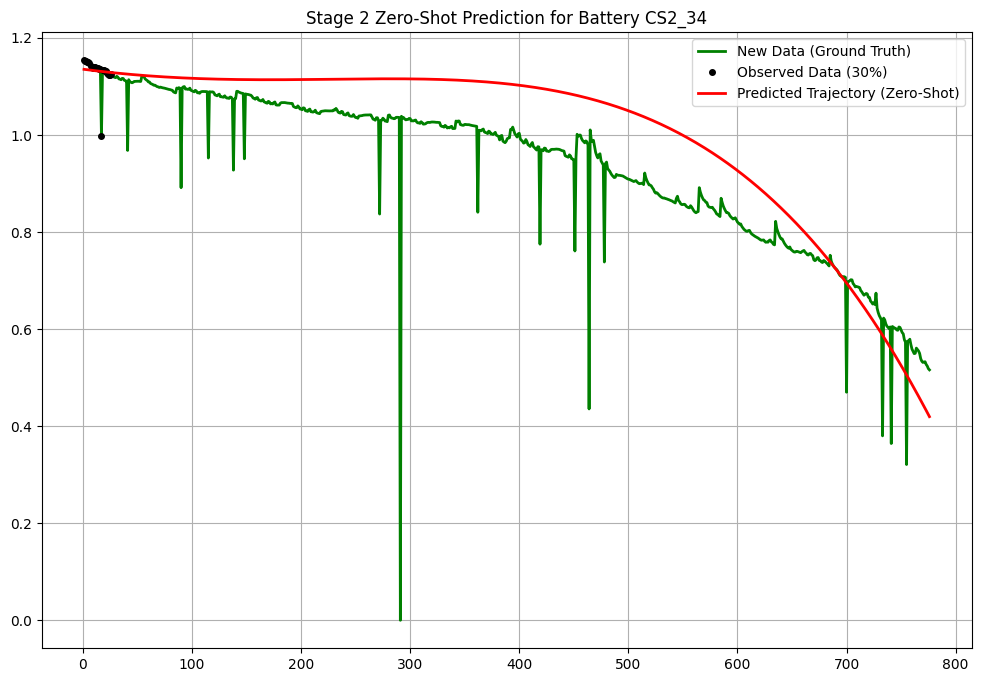


--- Zero-Shot Trajectory Performance ---
R²: 0.5928


In [ ]:
#  Zero-Shot Test for Stage 2 (Trajectory Prediction) 

#  1: Choose a battery from the new test set
# Index from 0 to len(X_test_new)
target_index_in_test_set = 1

#  2 RETRIEVE THE NECESSARY DATA 
target_battery_info = info_test[target_index_in_test_set]
predicted_cycle_life_new = y_pred_zeroshot[target_index_in_test_set] # Use zero-shot prediction
true_cycle_life_new = target_battery_info['cycle_life']

print(f"Running Stage 2 ZERO-SHOT Test on: {target_battery_info['name']} ---")
print(f"Using Predicted Cycle Life: {predicted_cycle_life_new:.0f} (True: {true_cycle_life_new})")

# 3 PREPARE TARGET DATA FOR MCMC
new_ground_truth_capacity = target_battery_info['capacities']
new_ground_truth_cycles = np.arange(1, len(new_ground_truth_capacity) + 1)
new_split_cycle = int(0.3 * true_cycle_life_new)

observed_mask_new = new_ground_truth_cycles <= new_split_cycle
observed_cycles_new = new_ground_truth_cycles[observed_mask_new]
observed_capacity_new = new_ground_truth_capacity[observed_mask_new]

# 4 RUN MCMC SAMPLER
# Use the polynomial base model and parameters from the ORIGINAL MIT DATA
base_model_params_full = (poly_coeffs, source_cycles[0], source_battery['cycle_life'])
sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
    observed_cycles_new, observed_capacity_new, base_model_params_full, predicted_cycle_life_new, std_dev_prediction_error
))
p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
sampler.run_mcmc(p0, 5000, progress=True)
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

#  5 VISUALIZE AND EVALUATE 
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = source_cycles[0] - map_rho0 * observed_cycles_new[0]
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles[0] - rho0 * observed_cycles_new[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], new_ground_truth_cycles, poly_coeffs))
mean_prediction = np.mean(np.array(predictions), axis=0)

plt.figure(figsize=(12, 8))
plt.plot(new_ground_truth_cycles, new_ground_truth_capacity, 'g-', lw=2, label='New Data (Ground Truth)')
plt.plot(observed_cycles_new, observed_capacity_new, 'ko', markersize=4, label='Observed Data (30%)')
plt.plot(new_ground_truth_cycles, mean_prediction, 'r-', lw=2, label='Predicted Trajectory (Zero-Shot)')
plt.title(f"Stage 2 Zero-Shot Prediction for Battery {target_battery_info['name']}")
plt.legend(); plt.grid(True); plt.show()

test_start_index = len(observed_cycles_new)
y_true_test = new_ground_truth_capacity[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]
trajectory_r2 = r2_score(y_true_test, y_pred_test)

print(f"\n Zero-Shot Trajectory Performance")
print(f"R²: {trajectory_r2:.4f}")

# Few-shot transfer learning

In [ ]:
# Prepare Few-Shot Data
import pickle
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Load the prepared new data from the pickle file
with open('new_dataset_prepared.pkl', 'rb') as f:
    new_dataset = pickle.load(f)

vf_sequences = new_dataset['vf_sequences']
cycle_lives = new_dataset['cycle_lives']
batteries_info_new = new_dataset['batteries_info'] 

# all necessary outputs from the split 
X_finetune, X_test_new, y_finetune, y_test_new, info_finetune, info_test = train_test_split(
    vf_sequences, cycle_lives, batteries_info_new, test_size=0.4, random_state=42 # Using 70/30 split
)

print(f"New dataset split for few-shot learning:")
print(f"Fine-tuning set size: {len(X_finetune)}")
print(f"Test set size: {len(X_test_new)}")

# The rest of the cell is for fine-tuning Stage 1
# Create new scalers for the new dataset
y_scaler_new = StandardScaler()
y_finetune_scaled = y_scaler_new.fit_transform(y_finetune.reshape(-1, 1))

# Create a DataLoader for fine-tuning
finetune_dataset = TensorDataset(torch.FloatTensor(np.transpose(X_finetune, (0, 3, 1, 2))), torch.FloatTensor(y_finetune_scaled))
finetune_loader = DataLoader(finetune_dataset, batch_size=8, shuffle=True)

New dataset split for few-shot learning:
Fine-tuning set size: 3
Test set size: 3


In [ ]:
# Fine-Tune the Pre-Trained Model

# Load the pre-trained MIT model and fine-tune it
finetuned_model = ResCNN().to(device)
finetuned_model.load_state_dict(torch.load('resnet_cycle_predictor.pth')) # Load original weights
print(f"Loaded pre-trained weights from resnet_cycle_predictor.pth")

optimizer = optim.AdamW(finetuned_model.parameters(), lr=1e-4, weight_decay=0.0001)
criterion = nn.MSELoss()
epochs = 50

print("Starting fine-tuning on the new dataset...")
finetuned_model.train()
for epoch in range(epochs):
    for inputs, labels in finetune_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = finetuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

#  Save the newly fine-tuned model 
new_model_save_path = 'resnet_new_dataset_finetuned.pth'
torch.save(finetuned_model.state_dict(), new_model_save_path)
print(f"\nFine-tuning finished. Model saved to: {new_model_save_path}")

#  Evaluate the fine-tuned model 
finetuned_model.eval()
X_test_tensor = torch.FloatTensor(np.transpose(X_test_new, (0, 3, 1, 2))).to(device)
with torch.no_grad():
    predictions_scaled = finetuned_model(X_test_tensor)

y_pred_fewshot = y_scaler_new.inverse_transform(predictions_scaled.cpu().numpy())
r2_fewshot = r2_score(y_test_new, y_pred_fewshot)
print(f"\n--- Stage 1 (Cycle Life) FEW-SHOT Performance ---")
print(f"R² Score on new dataset's test set: {r2_fewshot:.4f}")

Loaded pre-trained weights from resnet_cycle_predictor.pth
Starting fine-tuning on the new dataset...

Fine-tuning finished. Model saved to: resnet_new_dataset_finetuned.pth

--- Stage 1 (Cycle Life) FEW-SHOT Performance ---
R² Score on new dataset's test set: -2.0666

Fine-tuning finished. Model saved to: resnet_new_dataset_finetuned.pth

--- Stage 1 (Cycle Life) FEW-SHOT Performance ---
R² Score on new dataset's test set: -2.0666


In [636]:
y_pred_fewshot, y_test_new

(array([[86.9441]], dtype=float32), array([85], dtype=int64))

In [665]:
#  Evaluate the Fine-Tuned Model

#   Load the fine-tuned model 
finetuned_model.load_state_dict(torch.load(new_model_save_path))
finetuned_model.eval()

#   Predict on the new test set 
X_test_tensor = torch.FloatTensor(np.transpose(X_test_new, (0, 3, 1, 2))).to(device)
with torch.no_grad():
    predictions_scaled = finetuned_model(X_test_tensor)

# Inverse transform using the new scaler
y_pred_fewshot = y_scaler_new.inverse_transform(predictions_scaled.cpu().numpy())

#  Calculate and Print Stage 1 Few-Shot Metrics ---
s1_r2_few = r2_score(y_test_new, y_pred_fewshot)
s1_mae_few = mean_absolute_error(y_test_new, y_pred_fewshot)
s1_rmse_few = np.sqrt(mean_squared_error(y_test_new, y_pred_fewshot))
s1_mape_few = mean_absolute_percentage_error(y_test_new, y_pred_fewshot)

print(f"\n--- Stage 1 (Cycle Life) FEW-SHOT Performance on New Dataset ---")
print(f"R²:   {s1_r2_few:.4f}")
print(f"MAE:  {s1_mae_few:.2f} cycles")
print(f"RMSE: {s1_rmse_few:.2f} cycles")
print(f"MAPE: {s1_mape_few:.2f} %")


--- Stage 1 (Cycle Life) FEW-SHOT Performance on New Dataset ---
R²:   -2.0666
MAE:  13.50 cycles
RMSE: 15.94 cycles
MAPE: 18.35 %


The median cycle life of the new dataset is: 92 cycles.
Selected representative battery: 'CS2_34' (Cycle Life: 89)

Successfully created a new polynomial base model from the CS dataset.


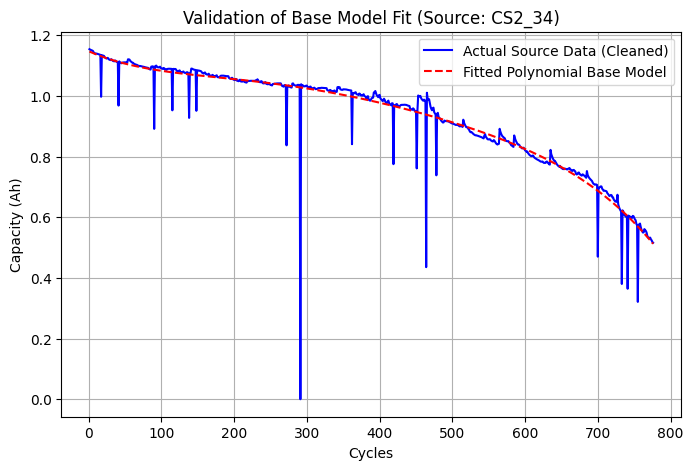

In [666]:
# Create the Base Model from a Representative CS Battery

# 1 Find a Representative Battery from the NEW dataset 
# Calculate the median cycle life of the new dataset
all_cycle_lives_new = [b['cycle_life'] for b in batteries_info_new]
median_cycle_life_new = np.median(all_cycle_lives_new)

# Find the battery with the cycle life closest to the median
representative_battery_new = min(batteries_info_new, key=lambda b: abs(b['cycle_life'] - median_cycle_life_new))
representative_battery_name_new = representative_battery_new['name']

print(f"The median cycle life of the new dataset is: {median_cycle_life_new:.0f} cycles.")
print(f"Selected representative battery: '{representative_battery_name_new}' (Cycle Life: {representative_battery_new['cycle_life']})")

# 2 Extract and Clean the Data for the Representative Battery 
# We use the full capacity curve for the base model
source_capacity = representative_battery_new['capacities']
source_cycles = np.arange(1, len(source_capacity) + 1)

#  3 Fit a Polynomial to the Representative Battery's Data
# A 4th-order or 5th polynomial is a robust choice for this type of curve
poly_coeffs_new = np.polyfit(source_cycles, source_capacity,5)
print("\nSuccessfully created a new polynomial base model from the CS dataset.")

#  4 Visualize and Validate the New Base Model Fit 
plt.figure(figsize=(8, 5))
plt.plot(source_cycles, source_capacity, 'b-', label='Actual Source Data (Cleaned)')
plt.plot(source_cycles, polynomial_model(source_cycles, poly_coeffs_new), 'r--', label='Fitted Polynomial Base Model')
plt.title(f"Validation of Base Model Fit (Source: {representative_battery_name_new})")
plt.xlabel("Cycles")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True)
plt.show()

--- Running Stage 2 FEW-SHOT Test on: CS2_33 ---
Using Predicted Cycle Life: 94 (True: 85)


100%|██████████| 5000/5000 [00:09<00:00, 510.40it/s]



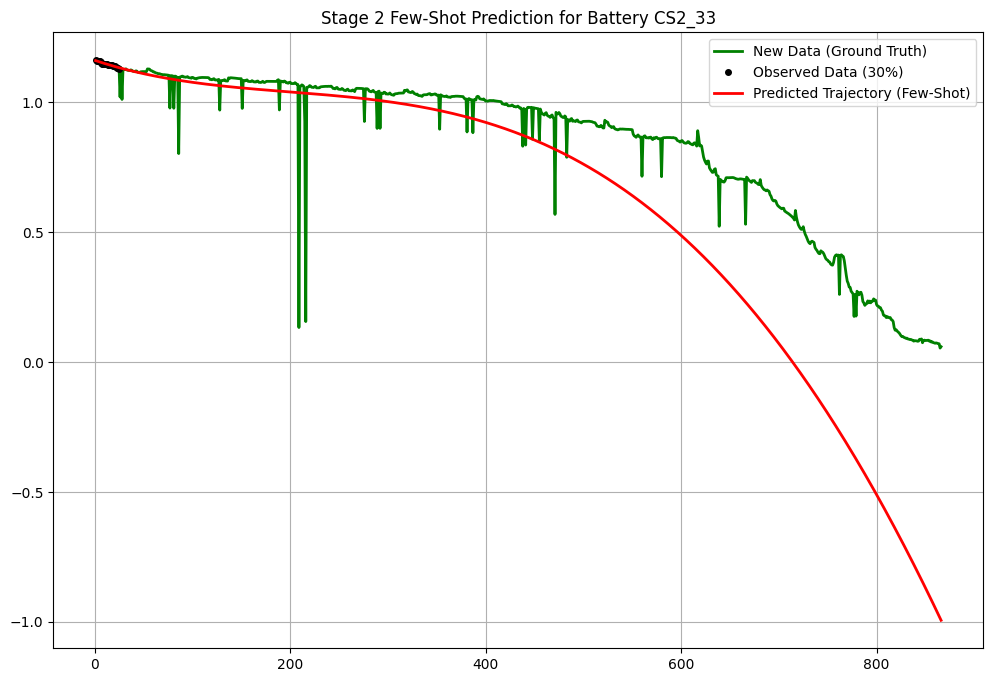


--- Few-Shot Trajectory Performance ---
R²: -0.4642


In [ ]:
#  Few-Shot Test for Stage 2 (Trajectory Prediction)

# Choose a battery from the new test set 
# Index from 0 to len(X_test_new)
target_index_in_test_set = 0

#  2 RETRIEVE THE NECESSARY DATA
target_battery_info = info_test[target_index_in_test_set]
predicted_cycle_life_new = y_pred_fewshot[target_index_in_test_set][0] # Use few-shot prediction
true_cycle_life_new = target_battery_info['cycle_life']

print(f"--- Running Stage 2 FEW-SHOT Test on: {target_battery_info['name']} ---")
print(f"Using Predicted Cycle Life: {predicted_cycle_life_new:.0f} (True: {true_cycle_life_new})")

# 3 PREPARE TARGET DATA FOR MCMC
new_ground_truth_capacity = target_battery_info['capacities']
new_ground_truth_cycles = np.arange(1, len(new_ground_truth_capacity) + 1)
new_split_cycle = int(0.3 * true_cycle_life_new)

observed_mask_new = new_ground_truth_cycles <= new_split_cycle
observed_cycles_new = new_ground_truth_cycles[observed_mask_new]
observed_capacity_new = new_ground_truth_capacity[observed_mask_new]

# 4 RUN MCMC SAMPLER 
# Use the NEW polynomial base model and fine-tuned prediction error
avg_source_life_new = np.mean([b['cycle_life'] for b in info_finetune])
base_model_params_full_new = (new_poly_coeffs, average_cycles[0], avg_source_life_new)
std_dev_prediction_error_new = np.std(y_test_new - y_pred_fewshot)

sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
    observed_cycles_new, observed_capacity_new, base_model_params_full_new, predicted_cycle_life_new, std_dev_prediction_error_new
))
p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
sampler.run_mcmc(p0, 5000, progress=True)
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

#  5 VISUALIZE AND EVALUATE 
map_rho0, map_rho1, map_lambda1 = np.median(flat_samples[:, :-1], axis=0)
map_lambda0 = average_cycles[0] - map_rho0 * observed_cycles_new[0]
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = average_cycles[0] - rho0 * observed_cycles_new[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], new_ground_truth_cycles, new_poly_coeffs))
mean_prediction = np.mean(np.array(predictions), axis=0)

plt.figure(figsize=(12, 8))
plt.plot(new_ground_truth_cycles, new_ground_truth_capacity, 'g-', lw=2, label='New Data (Ground Truth)')
plt.plot(observed_cycles_new, observed_capacity_new, 'ko', markersize=4, label='Observed Data (30%)')
plt.plot(new_ground_truth_cycles, mean_prediction, 'r-', lw=2, label='Predicted Trajectory (Few-Shot)')
plt.title(f"Stage 2 Few-Shot Prediction for Battery {target_battery_info['name']}")
plt.legend(); plt.grid(True); plt.show()

test_start_index = len(observed_cycles_new)
y_true_test = new_ground_truth_capacity[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]
trajectory_r2 = r2_score(y_true_test, y_pred_test)

print(f"\n--- Few-Shot Trajectory Performance ---")
print(f"R²: {trajectory_r2:.4f}")

# Testing Nasa Kaggle Dataset
# Zero-shot transfer learning

In [450]:
#pip install kagglehub

In [432]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mystifoe77/nasa-battery-data-cleaned")

print("Path to dataset files:", path)

100%|██████████| 136k/136k [00:00<00:00, 487kB/s]

Extracting files...
Path to dataset files: C:\Users\Zakar\.cache\kagglehub\datasets\mystifoe77\nasa-battery-data-cleaned\versions\1


In [692]:
import pandas as pd

kaggle_csv_path = 'C:/Users/zakar/.cache/kagglehub/datasets/mystifoe77/nasa-battery-data-cleaned/versions/1/Battery_Data_Cleaned.csv'

try:
    df = pd.read_csv(kaggle_csv_path)
    print(" CSV File Columns ")
    print(df.columns.tolist())
    
    print("\n First 5 Rows of the DataFrame ")
    display(df.head())
    
except FileNotFoundError:
    print(f"ERROR: The file was not found at the specified path: {kaggle_csv_path}")

 CSV File Columns 
['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']

 First 5 Rows of the DataFrame 


,type,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,-1,4,47,0,1,00001.csv,0.983689,0.054543,0.183130
1,0,24,47,1,2,00002.csv,0.983689,0.054543,0.183130
2,1,4,47,2,3,00003.csv,0.983689,0.054543,0.183130
3,0,24,47,3,4,00004.csv,0.983689,0.051825,0.152493
4,-1,4,47,4,5,00005.csv,0.925990,0.051825,0.152493


In [ ]:
import pandas as pd
import numpy as np
import pickle

def pad_to_length(array, target_length):
    if len(array) >= target_length:
        return array[:target_length]
    padding = np.full(target_length - len(array), array[-1] if len(array) > 0 else 0)
    return np.concatenate([array, padding])

def load_and_prepare_kaggle_nasa(file_path):
    """
    Loads and prepares the cleaned NASA dataset with the corrected cycle life calculation.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded {file_path}")
    except FileNotFoundError:
        print(f"ERROR: CSV file not found at {file_path}.")
        return None

    batteries_info = []
    vf_sequences_list = []
    cycle_lives = []

    for battery_id, battery_df in df.groupby('battery_id'):
        capacities = battery_df['Capacity'].values
        internal_resistance = battery_df['Re'].values
        cycle_indices = np.arange(1, len(battery_df) + 1)

        if len(capacities) > 0:
            initial_capacity = capacities[0]
            eol_threshold = initial_capacity * 0.80  # 80% of initial capacity
            
            # Find the first cycle where capacity drops below the threshold
            eol_cycles = np.where(capacities < eol_threshold)[0]
            cycle_life = eol_cycles[0] if len(eol_cycles) > 0 else len(capacities)
        else:
            cycle_life = 0

        if len(internal_resistance) < 10:
            continue

        vf_padded = pad_to_length(internal_resistance, 1000)
        cycle_indices_padded = pad_to_length(cycle_indices, 1000)
        sequence = np.stack([vf_padded, cycle_indices_padded], axis=1).reshape(1000, 2, 1)
        
        vf_sequences_list.append(sequence)
        cycle_lives.append(cycle_life)
        batteries_info.append({
            'name': f'NASA_Kaggle_{battery_id}',
            'cycle_life': cycle_life,
            'capacities': capacities
        })

    kaggle_vf_sequences = np.array(vf_sequences_list)
    kaggle_cycle_lives = np.array(cycle_lives)
    
    with open('kaggle_nasa_prepared.pkl', 'wb') as f:
        pickle.dump({
            'vf_sequences': kaggle_vf_sequences,
            'cycle_lives': kaggle_cycle_lives,
            'batteries_info': batteries_info
        }, f)
        
    print(f"\nData from {len(batteries_info)} batteries is ready for the experiments.")
    print(f"VF (Internal Resistance) sequences shape: {kaggle_vf_sequences.shape}")
    print("Data saved to 'kaggle_nasa_prepared.pkl'")

# 2. Run the function 
kaggle_csv_path = 'C:/Users/zakar/.cache/kagglehub/datasets/mystifoe77/nasa-battery-data-cleaned/versions/1/Battery_Data_Cleaned.csv'
load_and_prepare_kaggle_nasa(kaggle_csv_path)

Successfully loaded C:/Users/zakar/.cache/kagglehub/datasets/mystifoe77/nasa-battery-data-cleaned/versions/1/Battery_Data_Cleaned.csv

Data from 34 batteries is ready for the experiments.
VF (Internal Resistance) sequences shape: (34, 1000, 2, 1)
Data saved to 'kaggle_nasa_prepared.pkl'


In [445]:
nasa_dataset

{'vf_sequences': array([[[[-1.37109287e+02],
          [ 1.00000000e+00]],
 
         [[-1.33489470e+02],
          [ 7.04664263e-01]],
 
         [[-1.47723515e+02],
          [ 4.15900196e-01]],
 
         ...,
 
         [[-1.45189887e+02],
          [ 5.66229663e+00]],
 
         [[-1.45189887e+02],
          [ 5.66229663e+00]],
 
         [[-1.45189887e+02],
          [ 5.66229663e+00]]],
 
 
        [[[-1.36922063e+02],
          [ 1.00000000e+00]],
 
         [[-1.33306708e+02],
          [ 7.04664263e-01]],
 
         [[-1.47520724e+02],
          [ 4.15900196e-01]],
 
         ...,
 
         [[-1.44572994e+02],
          [ 5.66229663e+00]],
 
         [[-1.44572994e+02],
          [ 5.66229663e+00]],
 
         [[-1.44572994e+02],
          [ 5.66229663e+00]]],
 
 
        [[[-1.37690523e+02],
          [ 1.00000000e+00]],
 
         [[-1.34056858e+02],
          [ 7.04664263e-01]],
 
         [[-1.48353081e+02],
          [ 4.15900196e-01]],
 
         ...,
 
         [[-1.4

Loaded pre-trained model from resnet_cycle_predictor.pth
Successfully loaded the prepared NASA dataset.

--- Stage 1 (Cycle Life) ZERO-SHOT Performance on NASA Dataset ---
R²:   -12837.2988
MAE:  20281.46 cycles
RMSE: 20287.85 cycles


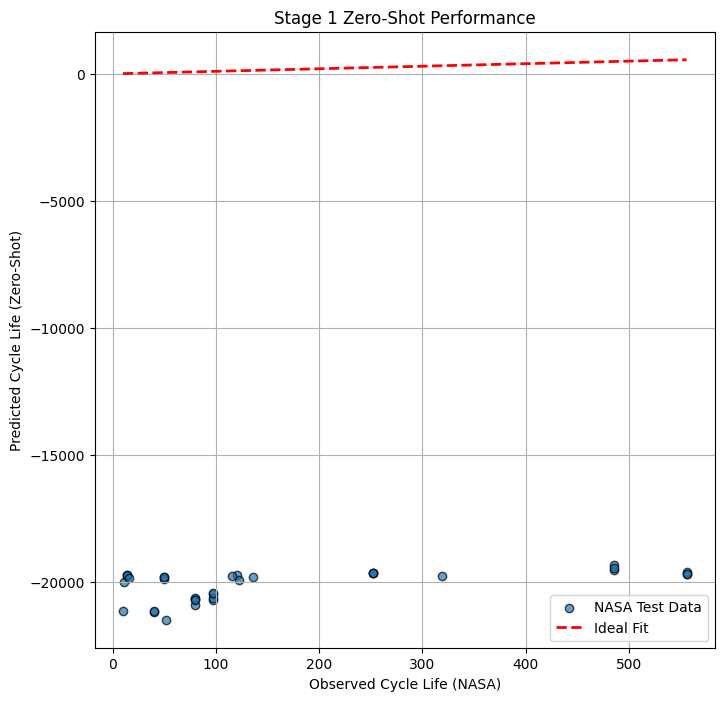

In [641]:
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#   Load the pre-trained MIT model 
mit_model_path = 'resnet_cycle_predictor.pth'
model = ResCNN().to(device)
model.load_state_dict(torch.load(mit_model_path))
model.eval()
print(f"Loaded pre-trained model from {mit_model_path}")

# Load the prepared NASA dataset
try:
    with open('kaggle_nasa_prepared.pkl', 'rb') as f:
        nasa_dataset = pickle.load(f)
    print("Successfully loaded the prepared NASA dataset.")
except FileNotFoundError:
    print("ERROR: 'kaggle_nasa_prepared.pkl' not found. Please run the NASA data prep cell first.")
    # Stop execution if the file is missing
    exit()

X_test_nasa = nasa_dataset['vf_sequences']
y_test_nasa = nasa_dataset['cycle_lives']

#  Perform Zero-Shot Prediction
# Reshape the data for the model: (N, H, W, C) -> (N, C, H, W)
X_test_nasa_torch = np.transpose(X_test_nasa, (0, 3, 1, 2))

#: Normalize the NASA data using the scalers from the MIT dataset
X_test_nasa_torch[:, 0, :, 0] = vf_scaler.transform(X_test_nasa_torch[:, 0, :, 0]) # Internal Resistance (as VF)
X_test_nasa_torch[:, 0, :, 1] = cycle_scaler.transform(X_test_nasa_torch[:, 0, :, 1]) # Cycle Indices

# Convert to tensor and predict
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_test_nasa_torch).to(device)
    predictions_scaled = model(X_tensor)
    
    # Inverse transform the predictions using the MIT y_scaler
    predictions_zeroshot = y_scaler.inverse_transform(predictions_scaled.cpu().numpy())

#  Evaluate Stage 1 Performance 
y_pred_s1 = predictions_zeroshot.flatten()
y_true_s1 = y_test_nasa.flatten()

s1_r2_zero = r2_score(y_true_s1, y_pred_s1)
s1_mae_zero = mean_absolute_error(y_true_s1, y_pred_s1)
s1_rmse_zero = np.sqrt(mean_squared_error(y_true_s1, y_pred_s1))

print(f"\n--- Stage 1 (Cycle Life) ZERO-SHOT Performance on NASA Dataset ---")
print(f"R²:   {s1_r2_zero:.4f}")
print(f"MAE:  {s1_mae_zero:.2f} cycles")
print(f"RMSE: {s1_rmse_zero:.2f} cycles")

#  5 Visualize Results
plt.figure(figsize=(8, 8))
plt.scatter(y_true_s1, y_pred_s1, alpha=0.7, edgecolors='k', label='NASA Test Data')
plt.plot([y_true_s1.min(), y_true_s1.max()], [y_true_s1.min(), y_true_s1.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel("Observed Cycle Life (NASA)")
plt.ylabel("Predicted Cycle Life (Zero-Shot)")
plt.title("Stage 1 Zero-Shot Performance")
plt.legend(); plt.grid(True); plt.show()

--- Running Stage 2 ZERO-SHOT Test on: NASA_Kaggle_5 ---
Using Predicted Cycle Life: -19675 (True: 556)


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:08<00:00, 592.17it/s]


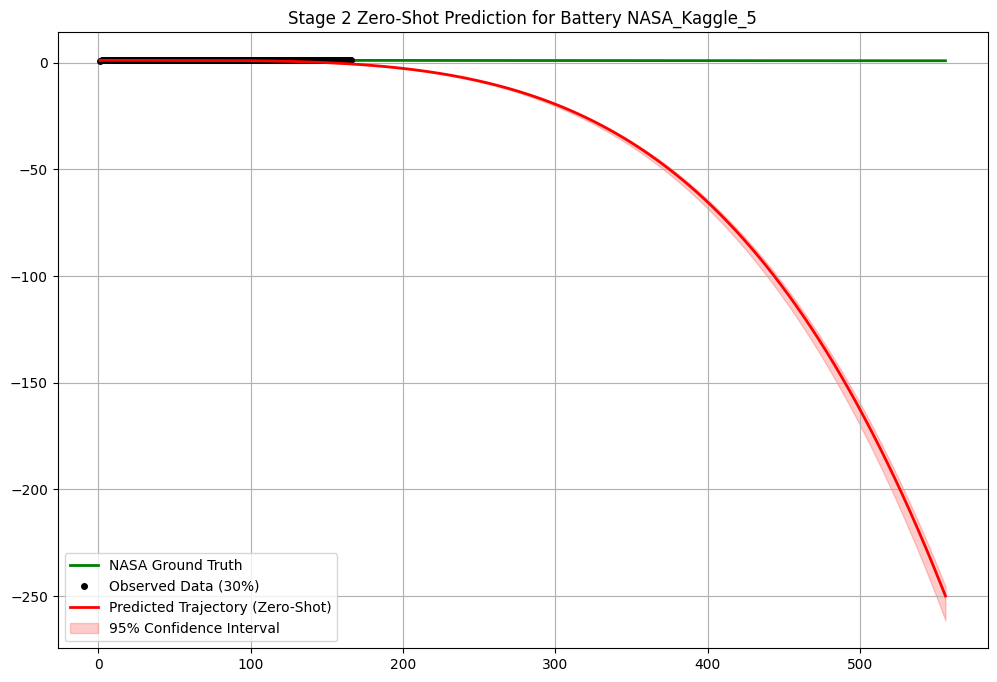


--- Zero-Shot Trajectory Prediction Performance ---
R² : -4199573.0534
MAE :  71.0388 Ah


In [643]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# Ensure all necessary variables from your previous cells are in memory 

# Choose a battery from the NASA test set to evaluate (e.g., the first one, index 0)
target_index_in_nasa_set = 0

# RETRIEVE DATA 
target_battery_info = nasa_dataset['batteries_info'][target_index_in_nasa_set]
predicted_cycle_life_new = y_pred_s1[target_index_in_nasa_set]
true_cycle_life_new = target_battery_info['cycle_life']

print(f"--- Running Stage 2 ZERO-SHOT Test on: {target_battery_info['name']} ---")
print(f"Using Predicted Cycle Life: {predicted_cycle_life_new:.0f} (True: {true_cycle_life_new})")

# PREPARE TARGET DATA FOR MCMC SAMPLER
new_ground_truth_capacity = target_battery_info['capacities']
new_ground_truth_cycles = np.arange(1, len(new_ground_truth_capacity) + 1)

new_split_cycle = int(0.3 * true_cycle_life_new)

observed_mask_new = new_ground_truth_cycles <= new_split_cycle
observed_cycles_new = new_ground_truth_cycles[observed_mask_new]
observed_capacity_new = new_ground_truth_capacity[observed_mask_new]

if len(observed_cycles_new) == 0:
    print(f"\nSKIPPING: Not enough observed data for battery {target_battery_info['name']}.")
    print(f"Its cycle life ({true_cycle_life_new}) is too short to get a 30% observation window.")
else:
    # RUN MCMC SAMPLER 
    # Using the polynomial base model from the ORIGINAL MIT DATA
    source_battery_mit = batteries_data[1]
    base_model_params_full = (poly_coeffs, source_cycles[0], source_battery_mit['cycle_life'])

    sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
        observed_cycles_new, 
        observed_capacity_new, 
        base_model_params_full, 
        predicted_cycle_life_new, 
        std_dev_prediction_error
    ))
    p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
    sampler.run_mcmc(p0, 5000, progress=True)
    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    #  VISUALIZE AND EVALUATE
    predictions = []
    for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
        rho0, rho1, lambda1 = p[:-1]
        lambda0 = source_cycles[0] - rho0 * observed_cycles_new[0]
        predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], new_ground_truth_cycles, poly_coeffs))

    mean_prediction = np.mean(np.array(predictions), axis=0)
    lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

    plt.figure(figsize=(12, 8))
    plt.plot(new_ground_truth_cycles, new_ground_truth_capacity, 'g-', lw=2, label='NASA Ground Truth')
    plt.plot(observed_cycles_new, observed_capacity_new, 'ko', markersize=4, label='Observed Data (30%)')
    plt.plot(new_ground_truth_cycles, mean_prediction, 'r-', lw=2, label='Predicted Trajectory (Zero-Shot)')
    plt.fill_between(new_ground_truth_cycles, lower_ci, upper_ci, color='red', alpha=0.2, label='95% Confidence Interval')
    plt.title(f"Stage 2 Zero-Shot Prediction for Battery {target_battery_info['name']}")
    plt.legend(); plt.grid(True); plt.show()

    # Calculate Final Metrics for the trajectory prediction
    test_start_index = len(observed_cycles_new)
    y_true_test = new_ground_truth_capacity[test_start_index:]
    y_pred_test = mean_prediction[test_start_index:]

    if len(y_true_test) > 1: # R² needs at least 2 data points
        trajectory_r2 = r2_score(y_true_test, y_pred_test)
        trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)

        print(f"\n--- Zero-Shot Trajectory Prediction Performance ---")
        print(f"R² : {trajectory_r2:.4f}")
        print(f"MAE :  {trajectory_mae:.4f} Ah")
    else:
        print("\nCould not calculate trajectory metrics: Not enough data points in the test portion.")

# Few-shot transfer learning

In [649]:
import pickle
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Load the prepared NASA data from the pickle file
with open('kaggle_nasa_prepared.pkl', 'rb') as f:
    nasa_dataset = pickle.load(f)

vf_sequences = nasa_dataset['vf_sequences']
cycle_lives = nasa_dataset['cycle_lives']
info_nasa = nasa_dataset['batteries_info'] # This list contains the battery details

# use a small number of batteries for fine-tuning (e.g., 9) and the rest for testing. Im trying 50% for fine tuning, to see how it performs.
X_finetune, X_test_fewshot, y_finetune, y_test_fewshot, info_finetune, info_test_fewshot = train_test_split(
    vf_sequences, cycle_lives, info_nasa, test_size=0.5, random_state=42
)

print(f"New dataset split for few-shot learning:")
print(f"Fine-tuning set size: {len(X_finetune)}")
print(f"Test set size: {len(X_test_fewshot)}")

# Create new scalers for the NASA dataset fine-tuning 
y_scaler_nasa = StandardScaler()
y_finetune_scaled = y_scaler_nasa.fit_transform(y_finetune.reshape(-1, 1))

# Create a DataLoader for the fine-tuning process
# Note: apply the original MIT scalers to the input features (X) later, during the training step.
finetune_dataset = TensorDataset(torch.FloatTensor(np.transpose(X_finetune, (0, 3, 1, 2))), torch.FloatTensor(y_finetune_scaled))
finetune_loader = DataLoader(finetune_dataset, batch_size=16, shuffle=True)

New dataset split for few-shot learning:
Fine-tuning set size: 17
Test set size: 17


In [ ]:
import torch.nn as nn
import torch.optim as optim

# Load the pre-trained MIT model to be fine-tuned 
finetuned_model = ResCNN().to(device)
finetuned_model.load_state_dict(torch.load('resnet_cycle_predictor.pth'))
print(f"Loaded pre-trained weights from resnet_cycle_predictor.pth")

# Its important to use the original MIT scalers to transform the input
# as this is the format the pre-trained model expects.
X_finetune_torch = np.transpose(X_finetune, (0, 3, 1, 2))
X_finetune_torch[:, 0, :, 0] = vf_scaler.transform(X_finetune_torch[:, 0, :, 0])
X_finetune_torch[:, 0, :, 1] = cycle_scaler.transform(X_finetune_torch[:, 0, :, 1])

# Create the final DataLoader with scaled inputs
y_finetune_torch_scaled = y_scaler_nasa.transform(y_finetune.reshape(-1, 1))
finetune_dataset_final = TensorDataset(torch.FloatTensor(X_finetune_torch), torch.FloatTensor(y_finetune_torch_scaled))
finetune_loader_final = DataLoader(finetune_dataset_final, batch_size=4, shuffle=True)

# Set up for fine-tuning
optimizer = optim.AdamW(finetuned_model.parameters(), lr=1e-5, weight_decay=0.0001) # Use a very small learning rate
criterion = nn.MSELoss()
epochs = 200

print("\nStarting fine-tuning on the new dataset...")
finetuned_model.train()
for epoch in range(epochs):
    for inputs, labels in finetune_loader_final:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = finetuned_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

#  Save the newly fine-tuned model
new_model_save_path = 'resnet_nasa_finetuned.pth'
torch.save(finetuned_model.state_dict(), new_model_save_path)
print(f"\nFine-tuning finished. Model saved to: {new_model_save_path}")

Loaded pre-trained weights from resnet_cycle_predictor.pth

Starting fine-tuning on the new dataset...

Fine-tuning finished. Model saved to: resnet_nasa_finetuned.pth


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load the fine-tuned model 
finetuned_model.load_state_dict(torch.load(new_model_save_path))
finetuned_model.eval()

# 2. Prepare the test data (using original MIT scalers for input) 
X_test_fewshot_torch = np.transpose(X_test_fewshot, (0, 3, 1, 2))
X_test_fewshot_torch[:, 0, :, 0] = vf_scaler.transform(X_test_fewshot_torch[:, 0, :, 0])
X_test_fewshot_torch[:, 0, :, 1] = cycle_scaler.transform(X_test_fewshot_torch[:, 0, :, 1])

# 3. Predict on the new test set
X_test_tensor = torch.FloatTensor(X_test_fewshot_torch).to(device)
with torch.no_grad():
    predictions_scaled = finetuned_model(X_test_tensor)

# Inverse transform using the new NASA-fitted scaler
y_pred_s1_fewshot = y_scaler_nasa.inverse_transform(predictions_scaled.cpu().numpy()).flatten()
y_true_s1_fewshot = y_test_fewshot.flatten()

#  4. Calculate and Print Stage 1 Few-Shot Metrics 
s1_r2_few = r2_score(y_true_s1_fewshot, y_pred_s1_fewshot)
s1_mae_few = mean_absolute_error(y_true_s1_fewshot, y_pred_s1_fewshot)
s1_rmse_few = np.sqrt(mean_squared_error(y_true_s1_fewshot, y_pred_s1_fewshot))

print(f"\nStage 1 (Cycle Life) FEW-SHOT Performance on NASA Test Set ")
print(f"R²:   {s1_r2_few:.4f}")
print(f"MAE:  {s1_mae_few:.2f} cycles")
print(f"RMSE: {s1_rmse_few:.2f} cycles")


Stage 1 (Cycle Life) FEW-SHOT Performance on NASA Test Set 
R²:   0.8687
MAE:  50.50 cycles
RMSE: 62.09 cycles


In [492]:
all_cycle_lives_nasa

[556,
 556,
 556,
 319,
 80,
 80,
 80,
 80,
 97,
 97,
 97,
 97,
 486,
 486,
 486,
 120,
 122,
 116,
 11,
 14,
 14,
 14,
 16,
 50,
 50,
 50,
 40,
 10,
 40,
 52,
 136,
 252,
 252,
 252]

Selected representative battery for base model: 'NASA_Kaggle_5' (Cycle Life: 556)

Training base model on data from cycle 6 onwards.
Successfully created a new polynomial base model.


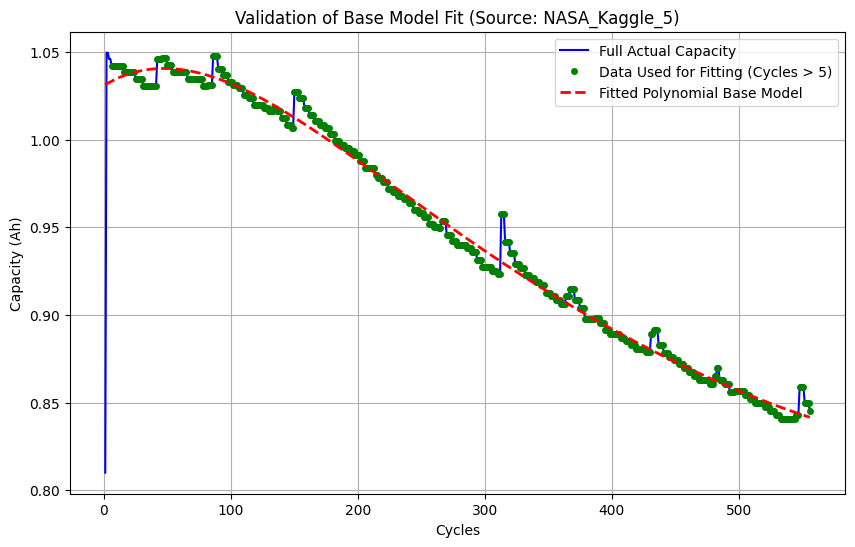

In [652]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
import pickle


#as always the same functions/appraoch 

#  Load the dataset to ensure all variables are defined
with open('kaggle_nasa_prepared.pkl', 'rb') as f:
    nasa_dataset = pickle.load(f)
info_nasa = nasa_dataset['batteries_info']

def polynomial_model(x, coeffs):
   
    return np.polyval(coeffs, x)

def transferred_model_poly(transfer_params, x_new, base_model_poly_params):
    """Applies the transfer learning transformation to the base polynomial model."""
    rho0, lambda0, rho1, lambda1 = transfer_params
    x_old = rho0 * x_new + lambda0
    C_old = polynomial_model(x_old, base_model_poly_params)
    C_new = rho1 * C_old + lambda1
    return C_new

# Create the Base Model from a Representative NASA Battery 
long_lived_batteries = [b for b in info_nasa if b['cycle_life'] > 300]
if not long_lived_batteries:
    print("Warning: No batteries found with more than 300 cycles. Using all batteries.")
    long_lived_batteries = info_nasa

all_cycle_lives_long = [b['cycle_life'] for b in long_lived_batteries]
median_cycle_life_long = np.median(all_cycle_lives_long)
rep_batt_nasa = long_lived_batteries[0]
rep_batt_name_nasa = rep_batt_nasa['name']

print(f"Selected representative battery for base model: '{rep_batt_name_nasa}' (Cycle Life: {rep_batt_nasa['cycle_life']})")

# Prepare Source Data, SKIPPING the first 5 cycles 
start_cycle_index = 5 # We start fitting from the 6th cycle (index 5)
full_source_capacity = rep_batt_nasa['capacities']
full_source_cycles = np.arange(1, len(full_source_capacity) + 1)

# Slice the data to exclude the initial cycles
source_capacity_fit = full_source_capacity[start_cycle_index:]
source_cycles_fit = full_source_cycles[start_cycle_index:]
print(f"\nTraining base model on data from cycle {start_cycle_index + 1} onwards.")

# Fit a 5th-order polynomial using the sliced data
poly_coeffs_nasa = np.polyfit(source_cycles_fit, source_capacity_fit, 5)
print("Successfully created a new polynomial base model.")

# --- 5. Visualize and Validate the New Base Model Fit ---
plt.figure(figsize=(10, 6))
# Plot the full curve for context
plt.plot(full_source_cycles, full_source_capacity, 'b-', label='Full Actual Capacity')
# Plot the data used for fitting
plt.plot(source_cycles_fit, source_capacity_fit, 'go', markersize=4, label=f'Data Used for Fitting (Cycles > {start_cycle_index})')
# Plot the fitted model over the full range
plt.plot(full_source_cycles, polynomial_model(full_source_cycles, poly_coeffs_nasa), 'r--', linewidth=2, label='Fitted Polynomial Base Model')
plt.title(f"Validation of Base Model Fit (Source: {rep_batt_name_nasa})")
plt.xlabel("Cycles"); plt.ylabel("Capacity (Ah)")
plt.legend(); plt.grid(True); plt.show()

In [599]:
info_test_fewshot

[{'name': 'NASA_Kaggle_38',
  'cycle_life': 120,
  'capacities': array([0.64083093, 0.64083093, 0.64083093, 0.64083093, 0.74318591,
         0.74318591, 0.7364845 , 0.7364845 , 0.72334897, 0.72334897,
         0.71035144, 0.71035144, 0.70655581, 0.70655581, 0.70655581,
         0.70655581, 0.73164743, 0.73164743, 0.73164743, 0.73164743,
         0.72459243, 0.72459243, 0.71130882, 0.71130882, 0.70849939,
         0.70849939, 0.70012699, 0.70012699, 0.69739619, 0.69739619,
         0.69739619, 0.69739619, 1.00866005, 1.00866005, 1.00866005,
         1.00866005, 1.02235807, 1.02235807, 1.02301431, 1.02301431,
         1.02370408, 1.02370408, 1.02476521, 1.02476521, 1.02460679,
         1.02460679, 1.02460679, 1.02460679, 1.02135406, 1.02135406,
         1.02135406, 1.02135406, 1.02296479, 1.02296479, 1.02458723,
         1.02458723, 1.02432271, 1.02432271, 1.02374384, 1.02374384,
         1.02233521, 1.02233521, 1.02233521, 1.02233521, 1.02392835,
         1.02392835, 1.02363844, 1.02363


--- Running Stage 2 FEW-SHOT Test on: NASA_Kaggle_33 ---
Using Predicted Cycle Life: 443 (True: 486)
Using observed data from cycle 1 to 145.


 10%|█         | 516/5000 [00:01<00:10, 411.59it/s]

100%|██████████| 5000/5000 [00:11<00:00, 443.24it/s]


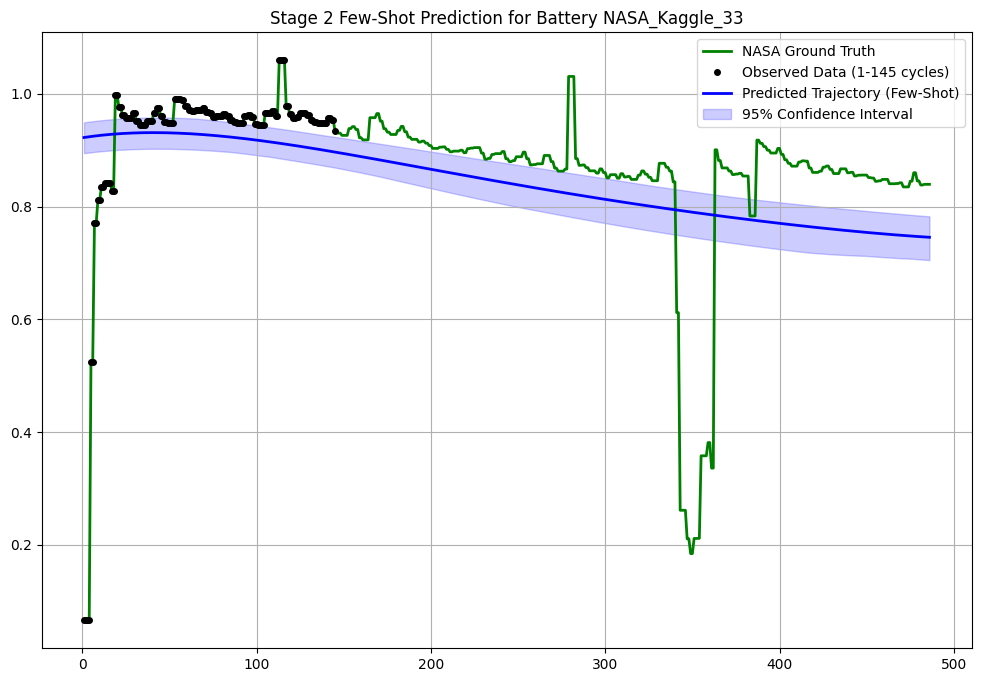


 Few-Shot Trajectory Prediction Performance
R²: 0.0231
MAE: 0.0968 Ah


In [ ]:
#  Select a Target Battery from the NASA test set
target_index_in_test_set = 7
target_battery_info = info_test_fewshot[target_index_in_test_set]
predicted_cycle_life_fewshot = y_pred_s1_fewshot[target_index_in_test_set]
true_cycle_life_new = target_battery_info['cycle_life']

print(f"\n--- Running Stage 2 FEW-SHOT Test on: {target_battery_info['name']} ---")
print(f"Using Predicted Cycle Life: {predicted_cycle_life_fewshot:.0f} (True: {true_cycle_life_new})")

#  Prepare Target Data, SKIPPING the first 5 cycles
start_cycle_obs = 0 # Start observing from cycle 6
split_cycle_obs = int(0.3 * true_cycle_life_new) # Observe up to 60% of life

new_ground_truth_capacity = target_battery_info['capacities']
new_ground_truth_cycles = np.arange(1, len(new_ground_truth_capacity) + 1)

# Create a boolean mask for the desired cycle range
observed_mask = (new_ground_truth_cycles > start_cycle_obs) & (new_ground_truth_cycles <= split_cycle_obs)

observed_cycles_new = new_ground_truth_cycles[observed_mask]
observed_capacity_new = new_ground_truth_capacity[observed_mask]
print(f"Using observed data from cycle {observed_cycles_new[0]} to {observed_cycles_new[-1]}.")


#  Prepare Priors and RUN MCMC SAMPLER 
errors_fewshot = y_pred_s1_fewshot - y_test_fewshot
std_dev_prediction_error_nasa = np.std(errors_fewshot)
base_model_params_nasa = (poly_coeffs_nasa, source_cycles_nasa[0], rep_batt_nasa['cycle_life'])

sampler = emcee.EnsembleSampler(32, 4, log_probability_poly, args=(
    observed_cycles_new, 
    observed_capacity_new, 
    base_model_params_nasa, 
    predicted_cycle_life_fewshot, 
    std_dev_prediction_error_nasa
))
p0 = np.array([1.0, 1.0, 0.0, np.log(0.01)]) + 1e-3 * np.random.randn(32, 4)
sampler.run_mcmc(p0, 5000, progress=True)
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# Visualize and Evaluate Trajectory Prediction 
predictions = []
for p in flat_samples[np.random.randint(len(flat_samples), size=100)]:
    rho0, rho1, lambda1 = p[:-1]
    lambda0 = source_cycles_nasa[0] - rho0 * observed_cycles_new[0]
    predictions.append(transferred_model_poly([rho0, lambda0, rho1, lambda1], new_ground_truth_cycles, poly_coeffs_nasa))

mean_prediction = np.mean(np.array(predictions), axis=0)
lower_ci, upper_ci = np.percentile(np.array(predictions), [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 8))
plt.plot(new_ground_truth_cycles, new_ground_truth_capacity, 'g-', lw=2, label='NASA Ground Truth')
plt.plot(observed_cycles_new, observed_capacity_new, 'ko', markersize=4, label=f'Observed Data ({start_cycle_obs+1}-{split_cycle_obs} cycles)')
plt.plot(new_ground_truth_cycles, mean_prediction, 'b-', lw=2, label='Predicted Trajectory (Few-Shot)')
plt.fill_between(new_ground_truth_cycles, lower_ci, upper_ci, color='blue', alpha=0.2, label='95% Confidence Interval')
plt.title(f"Stage 2 Few-Shot Prediction for Battery {target_battery_info['name']}")
plt.legend(); plt.grid(True); plt.show()

#  Metrics 
test_start_index = len(observed_cycles_new)
y_true_test = new_ground_truth_capacity[test_start_index:]
y_pred_test = mean_prediction[test_start_index:]

if len(y_true_test) > 1:
    trajectory_r2 = r2_score(y_true_test, y_pred_test)
    trajectory_mae = mean_absolute_error(y_true_test, y_pred_test)

    print(f"\n Few-Shot Trajectory Prediction Performance")
    print(f"R²: {trajectory_r2:.4f}")
    print(f"MAE: {trajectory_mae:.4f} Ah")